# Project dependencies

In [1]:
import sys
import subprocess

def install_requirements(requirements_file="requirements.txt"):
    try:
        print(f"Installing dependencies from {requirements_file}...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-r", requirements_file],
            check=True
        )
        print("Dependencies installed successfully!")
    except subprocess.CalledProcessError as e:
        print(f"Error installing dependencies: {e}")


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import time
import json
import gc
import pickle
import os
import re
from math import sqrt
from multiprocessing import Process, Queue

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import openml

from pymfe.mfe import MFE
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer, SimpleImputer

from joblib import Parallel, delayed
from tabulate import tabulate

from scipy import stats
from scipy.stats import spearmanr, rankdata, friedmanchisquare

from sklearn import decomposition, neighbors
from sklearn.cross_decomposition import CCA
from sklearn.datasets import make_classification, make_multilabel_classification
from sklearn.decomposition import (
    PCA, FastICA, KernelPCA, TruncatedSVD, FactorAnalysis,
    NMF, IncrementalPCA, LatentDirichletAllocation, SparseCoder
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.manifold import TSNE, LocallyLinearEmbedding, SpectralEmbedding
from sklearn.metrics import (
    mean_squared_error, classification_report, f1_score,
    precision_score, recall_score
)
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    LeaveOneOut, StratifiedKFold, KFold
)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.utils import shuffle

from mlxtend.evaluate import paired_ttest_5x2cv

## Loading datasets from the [OpenML](https://www.openml.org/) repository

Esta célula inicializa a sessão do Spark. Os parâmetros de memória estão ajustados para suportar a conversão direta em memória dos datasets baixados para dataframes do Spark.

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Encerra qualquer sessão pré-existente para evitar conflitos de memória
try:
    spark.stop()
except:
    pass

# Inicialização do cluster local ajustado para Ingestão
spark = SparkSession.builder \
    .appName("OpenML Direct Ingestion to Parquet") \
    .master("local[2]") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "12g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

# Definição dos caminhos dos diretórios (eliminamos o diretório de CSV)
OUTPUT_METADATA = "data/spark/final_openml_datasets.parquet"
OUTPUT_PARQUET = "data/spark/datasets_parquet"
OUTPUT_ERRORS = "data/spark/download_errors.csv"
OUTPUT_TIMES = "data/spark/download_times.csv"

# Cria o diretório de destino dos parquets, se não existir
os.makedirs(OUTPUT_PARQUET, exist_ok=True)

print("Sessão Spark iniciada e diretórios configurados.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/24 09:52:15 WARN Utils: Your hostname, latitude, resolves to a loopback address: 127.0.1.1; using 192.168.0.9 instead (on interface wlp114s0f0)
26/06/24 09:52:15 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/24 09:52:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sessão Spark iniciada e diretórios configurados.


Aqui aplicamos as regras de negócio para selecionar quais bases farão parte do experimento de meta-aprendizagem. Usar o Spark para filtrar os metadados antes do download garante que você só consuma banda e processamento para datasets que realmente importam para o escopo de recomendação de redução de dimensionalidade.

In [ ]:
from pyspark.sql.functions import col, regexp_extract

# Célula 2: Busca e Filtragem do Catálogo do OpenML
print("Buscando catálogo de datasets no OpenML...")
all_datasets_pd = openml.datasets.list_datasets(output_format="dataframe")
print(f"Total de datasets no OpenML: {len(all_datasets_pd)}")

# Transforma os metadados em DataFrame Spark para filtragem otimizada
spark_datasets = spark.createDataFrame(all_datasets_pd).repartition(4)

filtered_datasets = spark_datasets.filter(
    (col("NumberOfInstances") >= 200) &
    (col("NumberOfInstances") <= 10000) &
    (col("NumberOfFeatures") >= 2) &
    (col("NumberOfFeatures") <= 50) &
    (col("NumberOfClasses") >= 2) &
    (col("NumberOfClasses") <= 6) &
    (col("NumberOfInstancesWithMissingValues") < col("NumberOfInstances") * 0.3) &
    (col("MinorityClassSize") >= 20) &
    (col("NumberOfNumericFeatures") == col("NumberOfFeatures") - 1) &
    (col("NumberOfInstances") * col("NumberOfFeatures") <= 60000)
).dropDuplicates(["name"])

print(f"Quantidade de datasets elegíveis após filtros: {filtered_datasets.count()}")

# Remove datasets da mesma família com base no primeiro grupo de letras do nome
filtered_datasets = filtered_datasets.withColumn(
    "family",
    regexp_extract(col("name"), r"([a-zA-Z]+)", 1)
)

final_datasets = filtered_datasets.dropDuplicates(["family"])

# Remove datasets FOREX
final_datasets = final_datasets.filter(
    ~col("name").rlike("(?i)FOREX")
)

print(f"Quantidade de datasets após remoção de famílias: {final_datasets.count()}")

# Salva os metadados filtrados para controle e auditoria
final_datasets.write.mode("overwrite").parquet(OUTPUT_METADATA)

# Coleta apenas as colunas necessárias para o driver orientar o download
datasets_to_download = final_datasets.select(
    "did", "name", "NumberOfInstances", "NumberOfFeatures", "NumberOfClasses"
).collect()

Buscando catálogo de datasets no OpenML...
Total de datasets no OpenML: 6408


Quantidade de datasets elegíveis após filtros: 329
Quantidade de datasets após remoção de famílias e FOREX: 94


In [ ]:

df = final_datasets.select(
    "NumberOfInstances",
    "NumberOfFeatures",
    "NumberOfClasses"
).toPandas()

stats = {
    "Instances": [
        df["NumberOfInstances"].min(),
        df["NumberOfInstances"].median(),
        df["NumberOfInstances"].mean(),
        df["NumberOfInstances"].max()
    ],
    "Features": [
        df["NumberOfFeatures"].min(),
        df["NumberOfFeatures"].median(),
        df["NumberOfFeatures"].mean(),
        df["NumberOfFeatures"].max()
    ],
    "Classes": [
        df["NumberOfClasses"].min(),
        df["NumberOfClasses"].median(),
        df["NumberOfClasses"].mean(),
        df["NumberOfClasses"].max()
    ]
}

labels = ["min", "median", "mean", "max"]

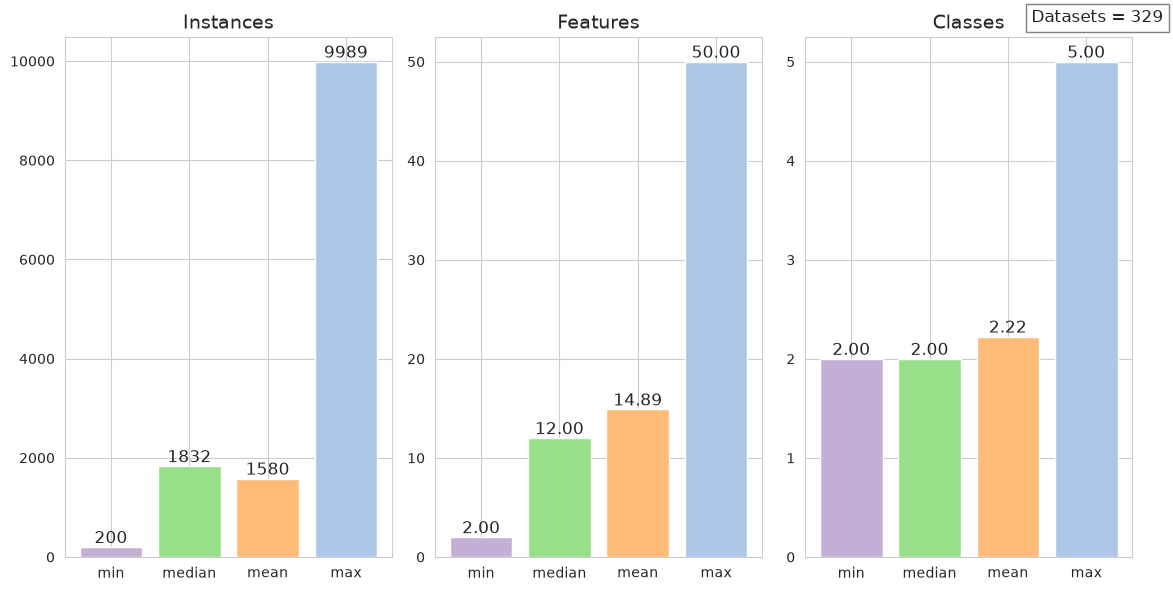

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12,6))

titles = ["Instances", "Features", "Classes"]

for ax, title in zip(axes, titles):

    values = stats[title]

    bars = ax.bar(
        labels,
        values,
        color=["#c5b0d5", "#98df8a", "#ffbb78", "#aec7e8"]
    )

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{value:.2f}" if value < 100 else f"{value:.0f}",
            ha='center',
            va='bottom',
            fontsize=12
        )

    ax.set_title(title, fontsize=14)

axes[2].text(
    2.3,
    max(stats["Classes"]) * 1.08,
    f"Datasets = {len(df)}",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="gray")
)

plt.tight_layout()
plt.savefig(
    "summary_datasets.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

 O script itera sobre a lista de datasets elegíveis, faz a requisição na API do OpenML, recebe os dados em memória (via Pandas) e imediatamente os converte para um RDD/DataFrame do Spark. O Spark então particiona esses dados e os escreve diretamente em formato Parquet. Isso elimina o passo intermediário de salvar e ler arquivos .csv.

In [29]:
# Célula 3: Pipeline de Download e Conversão Direta para Parquet
errors = []
download_times = []

def safe_name(name):
    name = str(name)
    name = re.sub(r"[^a-zA-Z0-9_\-]+", "_", name)
    return name[:100]

print("Iniciando pipeline de ingestão direta para Parquet...")

for row in datasets_to_download:
    did = int(row["did"])
    name = row["name"]
    dataset_name = safe_name(name)

    instances = row["NumberOfInstances"]
    features = row["NumberOfFeatures"]
    classes = row["NumberOfClasses"]
    cells = instances * features

    # Agora o destino final já é a pasta Parquet
    output_path = f"{OUTPUT_PARQUET}/{did}_{dataset_name}"

    if os.path.exists(output_path):
        print(f"Pulando {did} - {name}, parquet já existe.")
        continue

    start = time.time()
    print(f"Processando {did} - {name} ...", end=" ")

    try:
        # 1. Download via OpenML (retorna Pandas/NumPy na memória)
        ds = openml.datasets.get_dataset(did)
        target_col = ds.default_target_attribute

        if target_col is None:
            raise ValueError("Dataset sem target padrão no OpenML")

        X, y, _, _ = ds.get_data(dataset_format="dataframe", target=target_col)

        # 2. Prepara o Pandas DataFrame na memória
        pdf = X.copy()
        pdf["target"] = y
        pdf["openml_did"] = did
        pdf["dataset_name"] = dataset_name
        
        # Tratamento rápido de tipos para evitar falhas de inferência no Spark
        for col_name in pdf.columns:
            if str(pdf[col_name].dtype) == 'category':
                pdf[col_name] = pdf[col_name].astype(str)

        # 3. Conversão Imediata: Memória (Pandas) -> Cluster (Spark DF)
        spark_df = spark.createDataFrame(pdf)

        # 4. Escrita Otimizada: Spark escreve em Parquet particionado
        spark_df.repartition(4).write.mode("overwrite").parquet(output_path)

        elapsed = time.time() - start

        download_times.append({
            "did": did, "name": name, "instances": instances,
            "features": features, "classes": classes, "cells": cells,
            "target_column": target_col, "processing_time_seconds": elapsed,
            "status": "success", "output_path": output_path
        })
        
        # Atualiza log de tempos incrementalmente
        pd.DataFrame(download_times).to_csv(OUTPUT_TIMES, index=False)
        print(f"OK ({elapsed:.2f}s) - Salvo como Parquet")

    except Exception as e:
        elapsed = time.time() - start
        
        errors.append({
            "did": did, "name": name, "instances": instances,
            "features": features, "classes": classes, "cells": cells,
            "error": str(e), "time_seconds": elapsed
        })

        download_times.append({
            "did": did, "name": name, "instances": instances,
            "features": features, "classes": classes, "cells": cells,
            "target_column": None, "processing_time_seconds": elapsed,
            "status": "error", "output_path": None
        })

        pd.DataFrame(errors).to_csv(OUTPUT_ERRORS, index=False)
        pd.DataFrame(download_times).to_csv(OUTPUT_TIMES, index=False)
        print(f"ERRO ({elapsed:.2f}s): {e}")

print("\nIngestão finalizada.")
print(f"Datasets ingeridos e salvos como Parquet em: {OUTPUT_PARQUET}")

Iniciando pipeline de ingestão direta para Parquet...
Processando 46435 - Apple_Stock_Price_Trends_Classification ... OK (0.57s) - Salvo como Parquet
Processando 41919 - CPMP-2015-runtime-classification ... OK (0.32s) - Salvo como Parquet
Processando 1447 - CastMetal1 ... OK (0.30s) - Salvo como Parquet
Processando 1446 - CostaMadre1 ... OK (0.30s) - Salvo como Parquet
Processando 46416 - Creditability-German-Credit-Data ... OK (0.30s) - Salvo como Parquet
Processando 46562 - German-Credit-Data-Creditability-Preprocessed-Dataset ... OK (0.35s) - Salvo como Parquet
Processando 44417 - Higgs_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True ... OK (0.19s) - Salvo como Parquet
Processando 44400 - MagicTelescope_seed_3_nrows_2000_nclasses_10_ncols_100_stratify_True ... OK (0.18s) - Salvo como Parquet
Processando 1449 - MeanWhile1 ... OK (0.29s) - Salvo como Parquet
Processando 1442 - MegaWatt1 ... OK (0.26s) - Salvo como Parquet
Processando 1451 - PieChart1 ... OK (0.31s) - Salvo como 

# Extracting meta-features from the datasets

In [30]:
import os
import pandas as pd
from pyspark.sql import SparkSession

# 1. CONFIGURAÇÃO DO AMBIENTE E GERENCIAMENTO DE RECURSOS
# Aqui garantimos que o Spark está configurado para lidar com o volume 
# de dados de forma paralelizada, alocando memória suficiente para o driver.
spark = SparkSession.builder \
    .appName("Distributed MetaFeature Extraction") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

DATA_PATH = "data/spark/datasets_parquet"

# Levantamento dos datasets disponíveis no diretório
dataset_folders = sorted([d for d in os.listdir(DATA_PATH) if not d.startswith('.')])
print(f"Total de datasets enfileirados para processamento distribuído: {len(dataset_folders)}")


Total de datasets enfileirados para processamento distribuído: 94


26/06/24 16:34:57 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [31]:

# 2. DEFINIÇÃO DA TAREFA DO WORKER (FUNÇÃO ISOLADA)
# Esta função será serializada e enviada para os nós de processamento (workers).
# Todos os imports e dependências devem ocorrer DENTRO da função para 
# evitar problemas de contexto aninhado e falhas de serialização (Pickle) no Spark.
def process_single_dataset(dataset_name):
    """
    Função autocontida executada em paralelo pelos workers do Spark.
    Realiza a ingestão direta do Parquet, tratamento de dados e extração das metafeatures.
    """
    from pymfe.mfe import MFE
    from sklearn.preprocessing import LabelEncoder
    from sklearn.impute import KNNImputer, SimpleImputer
    
    start_time = time.time()
    
    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]
    # Em um cluster real, este caminho apontaria para um HDFS ou S3 bucket
    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}" 
    MAX_ROWS = 10000
    
    result = {
        "dataset": dataset_name,
        "status": "success",
        "error": None,
        "time_seconds": 0.0
    }
    
    try:
        # O Worker lê sua própria partição de dados do disco (arquitetura Shared-Nothing)
        pdf = pd.read_parquet(FILE_PATH)
        
        # Controle de volumetria em memória por worker
        if len(pdf) > MAX_ROWS:
            pdf = pdf.sample(n=MAX_ROWS, random_state=42)
            
        y = pdf[TARGET_COLUMN]
        X = pdf.drop(columns=[TARGET_COLUMN] + AUX_COLUMNS, errors="ignore")

        # Tratamento e Encoding
        for col in X.select_dtypes(include=["object", "category"]).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        X = X.apply(pd.to_numeric, errors="coerce")

        # Imputação de dados faltantes
        try:
            imputer = KNNImputer(n_neighbors=3)
            X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
        except Exception:
            imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
            X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        # Extração via PyMFE
        mfe = MFE(
            groups=["landmarking", "general", "statistical", "model-based", 
                    "info-theory", "relative", "clustering", "complexity", 
                    "itemset", "concept"],
            summary=["median", "min", "max", "mean", "sd", "quantiles", "histogram"]
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mfe.fit(X.values, y)
            ft_names, ft_values = mfe.extract()

        # Empacotamento dos resultados extraídos
        for name, value in zip(ft_names, ft_values):
            try:
                result[name] = float(value) if value is not None else np.nan
            except Exception:
                result[name] = np.nan
                
    except Exception as e:
        result["status"] = "error"
        result["error"] = str(e)
        
    result["time_seconds"] = time.time() - start_time
    return result


In [32]:

# 3. PARALELISMO E ORQUESTRAÇÃO MAP-REDUCE
# O Spark cria um RDD (Resilient Distributed Dataset) a partir da lista de arquivos.
# O método map() distribui a função process_single_dataset para o cluster.
print("Iniciando extração distribuída de metafeatures pelo cluster Spark...")

# O parâmetro numSlices define o particionamento. 
# Mapear 1 dataset por partição otimiza o uso dos executores.
rdd_datasets = spark.sparkContext.parallelize(dataset_folders, numSlices=len(dataset_folders))

# Aplica a função em paralelo (Transformação preguiçosa / Lazy Evaluation)
rdd_results = rdd_datasets.map(process_single_dataset)

# Ação (Action) que dispara a execução distribuída e coleta os resultados no nó mestre (Driver)
extracted_data = rdd_results.collect()

Iniciando extração distribuída de metafeatures pelo cluster Spark...


In [33]:

# 4. CONSOLIDAÇÃO E ARMAZENAMENTO DOS ARTEFATOS
# Redução e persistência dos dados consolidados gerados pelos workers.
successful_extractions = [res for res in extracted_data if res["status"] == "success"]
failed_extractions = [res for res in extracted_data if res["status"] == "error"]

print(f"\nProcessamento concluído!")
print(f"Sucessos: {len(successful_extractions)}")
print(f"Erros: {len(failed_extractions)}")

# Persistência de resultados com sucesso
if successful_extractions:
    df_metafeatures = pd.DataFrame(successful_extractions)
    
    df_metafeatures_clean = df_metafeatures.drop(columns=["status", "error", "time_seconds"])
    df_metafeatures_clean.to_csv("data/spark/meta_features_spark_distributed.csv", index=False)
    
    df_times = df_metafeatures[["dataset", "time_seconds", "status"]]
    df_times.to_csv("data/spark/meta_feature_times_distributed.csv", index=False)

# Persistência de logs de falhas para auditoria
if failed_extractions:
    df_errors = pd.DataFrame(failed_extractions)[["dataset", "error", "time_seconds"]]
    df_errors.to_csv("data/spark/meta_feature_errors_distributed.csv", index=False)
    
print("\nArtefatos (CSVs) de metafeatures, tempos e logs salvos com sucesso!")


Processamento concluído!
Sucessos: 94
Erros: 0

Artefatos (CSVs) de metafeatures, tempos e logs salvos com sucesso!


# Algorithm Performance Evaluation

## Classification with Dimensionality Reduction using KNN

### (PCA)

In [34]:
from pyspark.sql import SparkSession

# CONFIGURAÇÕES

DATA_PATH = "data/spark/datasets_parquet"

OUTPUT_CSV = "data/dimensionality_reduction/ClassificationWithReduction_PCA.csv"

dataset_folders = sorted(os.listdir(DATA_PATH))

print(f"Datasets encontrados: {len(dataset_folders)}")

# FUNÇÃO EXECUTADA PELOS WORKERS

def process_single_dataset_pca(dataset_name):

    warnings.filterwarnings("ignore")

    start_time = time.time()

    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]

    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}"

    k = 5
    MAX_ROWS = 2000

    result = {
        "Name": dataset_name,
        "Score": None,
        "Status": "success",
        "Error": None,
        "Time_seconds": 0.0
    }

    try:
        pdf = pd.read_parquet(FILE_PATH)

        if TARGET_COLUMN not in pdf.columns:
            raise ValueError("Coluna target não encontrada.")

        y = pdf[TARGET_COLUMN]

        X = pdf.drop(
            columns=[TARGET_COLUMN] + AUX_COLUMNS,
            errors="ignore"
        )

        X = pd.get_dummies(X)
        X = X.fillna(0)
        X = X.astype(float)

        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        if X.shape[0] > MAX_ROWS:
            X = X.iloc[:MAX_ROWS]
            y = y[:MAX_ROWS]

        if len(np.unique(y)) < 2:
            raise ValueError("Dataset possui menos de 2 classes.")

        X = StandardScaler().fit_transform(X)

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []

        for train_index, test_index in skf.split(X, y):

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            pca = PCA(n_components=0.95)

            X_train_pca = pca.fit_transform(X_train)
            X_test_pca = pca.transform(X_test)

            n_neighbors = min(k, len(X_train))

            neigh = KNeighborsClassifier(
                n_neighbors=n_neighbors
            )

            neigh.fit(X_train_pca, y_train)

            y_pred = neigh.predict(X_test_pca)

            score = f1_score(
                y_test,
                y_pred,
                average="micro"
            )

            f1_scores.append(score)

        mean_score = float(np.mean(f1_scores))

        result["Score"] = mean_score
        result["Time_seconds"] = time.time() - start_time

        print(f"[SUCCESS] {dataset_name} | Mean F1: {mean_score:.4f}")

        return result

    except Exception as e:

        result["Status"] = "error"
        result["Error"] = str(e)
        result["Time_seconds"] = time.time() - start_time

        print(f"[ERROR] {dataset_name}: {e}")

        return result


# EXECUÇÃO PARALELA COM SPARK

num_partitions = 4

results = (
    spark.sparkContext
    .parallelize(dataset_folders, numSlices=num_partitions)
    .map(process_single_dataset_pca)
    .collect()
)

# PROCESSAMENTO DOS RESULTADOS

dictionary = {
    "Name": [],
    "Score": []
}

skipped_datasets = []

for res in results:

    if res["Status"] == "error":

        skipped_datasets.append(
            f"{res['Name']}: {res['Error']}"
        )

        print(f"[SKIPPED] {res['Name']}: {res['Error']}")

    else:

        dictionary["Name"].append(res["Name"])
        dictionary["Score"].append(res["Score"])

        print(f"[DONE] {res['Name']} | Mean F1: {res['Score']:.4f}")

# SALVA RESULTADOS

os.makedirs(
    os.path.dirname(OUTPUT_CSV),
    exist_ok=True
)

pd.DataFrame(dictionary).to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

print(f"\nResultados salvos em:\n{OUTPUT_CSV}")

Datasets encontrados: 94


[SUCCESS] 1005_glass | Mean F1: 0.7709
[SUCCESS] 37_diabetes | Mean F1: 0.7330
[SUCCESS] 1048_jEdit_4_2_4_3 | Mean F1: 0.6234
[SUCCESS] 40671_ecoli | Mean F1: 0.8717
[SUCCESS] 40682_thyroid-new | Mean F1: 0.9349
[SUCCESS] 1068_pc1 | Mean F1: 0.9279
[SUCCESS] 40704_Titanic | Mean F1: 0.7585
[SUCCESS] 1071_mw1 | Mean F1: 0.9206
[SUCCESS] 1442_MegaWatt1 | Mean F1: 0.8973
[SUCCESS] 40994_climate-model-simulation-crashes | Mean F1: 0.9148
[SUCCESS] 1443_PizzaCutter1 | Mean F1: 0.9229
[SUCCESS] 41919_CPMP-2015-runtime-classification | Mean F1: 0.5103
[SUCCESS] 1446_CostaMadre1 | Mean F1: 0.8308
[SUCCESS] 41945_ilpd-numeric | Mean F1: 0.6485
[SUCCESS] 1447_CastMetal1 | Mean F1: 0.8533
[SUCCESS] 1449_MeanWhile1 | Mean F1: 0.8895
[SUCCESS] 44127_phoneme | Mean F1: 0.8280
[SUCCESS] 1451_PieChart1 | Mean F1: 0.9064
[SUCCESS] 44346_credit | Mean F1: 0.6160
[SUCCESS] 1460_banana | Mean F1: 0.8910
[SUCCESS] 1462_banknote-authentication | Mean F1: 0.9738
[SUCCESS] 44362_california_seed_0_nrows_2000_n

[DONE] 1005_glass | Mean F1: 0.7709
[DONE] 1048_jEdit_4_2_4_3 | Mean F1: 0.6234
[DONE] 1068_pc1 | Mean F1: 0.9279
[DONE] 1071_mw1 | Mean F1: 0.9206
[DONE] 1442_MegaWatt1 | Mean F1: 0.8973
[DONE] 1443_PizzaCutter1 | Mean F1: 0.9229
[DONE] 1446_CostaMadre1 | Mean F1: 0.8308
[DONE] 1447_CastMetal1 | Mean F1: 0.8533
[DONE] 1449_MeanWhile1 | Mean F1: 0.8895
[DONE] 1451_PieChart1 | Mean F1: 0.9064
[DONE] 1460_banana | Mean F1: 0.8910
[DONE] 1462_banknote-authentication | Mean F1: 0.9738
[DONE] 1499_seeds | Mean F1: 0.8952
[DONE] 1500_seismic-bumps | Mean F1: 0.9190
[DONE] 1508_user-knowledge | Mean F1: 0.7816
[DONE] 1510_wdbc | Mean F1: 0.9667
[DONE] 1524_vertebra-column | Mean F1: 0.8129
[DONE] 1525_wall-robot-navigation | Mean F1: 0.9770
[DONE] 1535_volcanoes-b5 | Mean F1: 0.9665
[DONE] 1547_autoUniv-au1-1000 | Mean F1: 0.7360
[DONE] 15_breast-w | Mean F1: 0.9714
[DONE] 311_oil_spill | Mean F1: 0.9658
[DONE] 337_SPECTF | Mean F1: 0.7364
[DONE] 37_diabetes | Mean F1: 0.7330
[DONE] 40671_eco

[SUCCESS] 962_mfeat-morphological | Mean F1: 0.9985
[SUCCESS] 994_vehicle | Mean F1: 0.9444==============>              (3 + 1) / 4]
[SUCCESS] 996_prnn_fglass | Mean F1: 0.7522
[SUCCESS] 997_balance-scale | Mean F1: 0.9040


### Kernel Principal Component Analysis (kPCA)

In [35]:
# CONFIGURAÇÕES

DATA_PATH = "data/spark/datasets_parquet"

OUTPUT_CSV = "data/dimensionality_reduction/ClassificationWithReduction_KPCA.csv"

dataset_folders = sorted(os.listdir(DATA_PATH))

print(f"Datasets encontrados: {len(dataset_folders)}")

# FUNÇÃO EXECUTADA PELOS WORKERS

def process_single_dataset_kpca(dataset_name):

    warnings.filterwarnings("ignore")

    start_time = time.time()

    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]

    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}"

    k = 5
    MAX_ROWS = 2000

    result = {
        "Name": dataset_name,
        "Score": None,
        "Status": "success",
        "Error": None,
        "Time_seconds": 0.0
    }

    try:
        pdf = pd.read_parquet(FILE_PATH)

        if TARGET_COLUMN not in pdf.columns:
            raise ValueError("Coluna target não encontrada.")

        y = pdf[TARGET_COLUMN]

        X = pdf.drop(
            columns=[TARGET_COLUMN] + AUX_COLUMNS,
            errors="ignore"
        )

        # Encoding das features categóricas
        for col in X.select_dtypes(include=["object", "category"]).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        # Valores ausentes
        X = X.fillna(0)

        # Float
        X = X.astype(float)

        # Encoding do target
        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        # Limita tamanho
        if X.shape[0] > MAX_ROWS:
            X = X.iloc[:MAX_ROWS]
            y = y[:MAX_ROWS]

        if len(np.unique(y)) < 2:
            raise ValueError("Dataset possui menos de 2 classes.")

        # Normalização
        X = StandardScaler().fit_transform(X)

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []

        for train_index, test_index in skf.split(X, y):

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            n_components = min(
                20,
                X_train.shape[1],
                X_train.shape[0] - 1
            )

            if n_components < 1:
                raise ValueError("Número inválido de componentes para KPCA.")

            kpca = KernelPCA(
                n_components=n_components,
                kernel="rbf",
                gamma=0.01,
                random_state=42
            )

            X_train_kpca = kpca.fit_transform(X_train)
            X_test_kpca = kpca.transform(X_test)

            n_neighbors = min(k, len(X_train_kpca))

            neigh = KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights="uniform",
                algorithm="auto",
                leaf_size=10,
                metric="minkowski",
                p=2
            )

            neigh.fit(X_train_kpca, y_train)

            y_pred = neigh.predict(X_test_kpca)

            score = f1_score(
                y_test,
                y_pred,
                average="micro"
            )

            f1_scores.append(score)

        mean_score = float(np.mean(f1_scores))

        result["Score"] = mean_score
        result["Time_seconds"] = time.time() - start_time

        print(f"[SUCCESS] {dataset_name} | Mean F1: {mean_score:.4f}")

        return result

    except Exception as e:

        result["Status"] = "error"
        result["Error"] = str(e)
        result["Time_seconds"] = time.time() - start_time

        print(f"[ERROR] {dataset_name}: {e}")

        return result


# EXECUÇÃO PARALELA COM SPARK

num_partitions = 4

results = (
    spark.sparkContext
    .parallelize(dataset_folders, numSlices=num_partitions)
    .map(process_single_dataset_kpca)
    .collect()
)

# PROCESSAMENTO DOS RESULTADOS

dictionary = {
    "Name": [],
    "Score": []
}

skipped_datasets = []

for res in results:

    if res["Status"] == "error":

        skipped_datasets.append(
            f"{res['Name']}: {res['Error']}"
        )

        print(f"[SKIPPED] {res['Name']}: {res['Error']}")

    else:

        dictionary["Name"].append(res["Name"])
        dictionary["Score"].append(res["Score"])

        print(f"[DONE] {res['Name']} | Mean F1: {res['Score']:.4f}")

# SALVA RESULTADOS

os.makedirs(
    os.path.dirname(OUTPUT_CSV),
    exist_ok=True
)

pd.DataFrame(dictionary).to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

print(f"\nResultados salvos em:\n{OUTPUT_CSV}")

Datasets encontrados: 94


[SUCCESS] 1005_glass | Mean F1: 0.7804
[SUCCESS] 37_diabetes | Mean F1: 0.7356
[SUCCESS] 1048_jEdit_4_2_4_3 | Mean F1: 0.6505
[SUCCESS] 40671_ecoli | Mean F1: 0.8930
[SUCCESS] 40682_thyroid-new | Mean F1: 0.9256
[SUCCESS] 1068_pc1 | Mean F1: 0.9306
[SUCCESS] 1071_mw1 | Mean F1: 0.9181
[SUCCESS] 40704_Titanic | Mean F1: 0.6825
[SUCCESS] 1442_MegaWatt1 | Mean F1: 0.8972
[SUCCESS] 40994_climate-model-simulation-crashes | Mean F1: 0.9222
[SUCCESS] 1443_PizzaCutter1 | Mean F1: 0.9274
[SUCCESS] 1446_CostaMadre1 | Mean F1: 0.8276                        (0 + 2) / 4]
[SUCCESS] 41919_CPMP-2015-runtime-classification | Mean F1: 0.5065
[SUCCESS] 1447_CastMetal1 | Mean F1: 0.8471
[SUCCESS] 41945_ilpd-numeric | Mean F1: 0.6451
[SUCCESS] 1449_MeanWhile1 | Mean F1: 0.8855
[SUCCESS] 1451_PieChart1 | Mean F1: 0.8993
[SUCCESS] 44127_phoneme | Mean F1: 0.8245
[SUCCESS] 1460_banana | Mean F1: 0.8895
[SUCCESS] 1462_banknote-authentication | Mean F1: 0.9985
[SUCCESS] 1499_seeds | Mean F1: 0.9190
[SUCCESS] 15

[DONE] 1005_glass | Mean F1: 0.7804
[DONE] 1048_jEdit_4_2_4_3 | Mean F1: 0.6505
[DONE] 1068_pc1 | Mean F1: 0.9306
[DONE] 1071_mw1 | Mean F1: 0.9181
[DONE] 1442_MegaWatt1 | Mean F1: 0.8972
[DONE] 1443_PizzaCutter1 | Mean F1: 0.9274
[DONE] 1446_CostaMadre1 | Mean F1: 0.8276
[DONE] 1447_CastMetal1 | Mean F1: 0.8471
[DONE] 1449_MeanWhile1 | Mean F1: 0.8855
[DONE] 1451_PieChart1 | Mean F1: 0.8993
[DONE] 1460_banana | Mean F1: 0.8895
[DONE] 1462_banknote-authentication | Mean F1: 0.9985
[DONE] 1499_seeds | Mean F1: 0.9190
[DONE] 1500_seismic-bumps | Mean F1: 0.9286
[DONE] 1508_user-knowledge | Mean F1: 0.7890
[DONE] 1510_wdbc | Mean F1: 0.9684
[DONE] 1524_vertebra-column | Mean F1: 0.8129
[DONE] 1525_wall-robot-navigation | Mean F1: 0.9780
[DONE] 1535_volcanoes-b5 | Mean F1: 0.9675
[DONE] 1547_autoUniv-au1-1000 | Mean F1: 0.7340
[DONE] 15_breast-w | Mean F1: 0.9700
[DONE] 311_oil_spill | Mean F1: 0.9669
[DONE] 337_SPECTF | Mean F1: 0.7879
[DONE] 37_diabetes | Mean F1: 0.7356
[DONE] 40671_eco

[SUCCESS] 997_balance-scale | Mean F1: 0.9008


### (Latent Dirichlet Allocation- LDA)

In [36]:

DATA_PATH = "data/spark/datasets_parquet"

OUTPUT_CSV = "data/dimensionality_reduction/ClassificationWithReduction_LDA.csv"

dataset_folders = sorted(os.listdir(DATA_PATH))

print(f"Datasets encontrados: {len(dataset_folders)}")

# FUNÇÃO EXECUTADA PELOS WORKERS

def process_single_dataset_lda(dataset_name):

    warnings.filterwarnings("ignore")

    start_time = time.time()

    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]

    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}"

    k = 5
    MAX_ROWS = 2000

    result = {
        "Name": dataset_name,
        "Score": None,
        "Status": "success",
        "Error": None,
        "Time_seconds": 0.0
    }

    try:
        pdf = pd.read_parquet(FILE_PATH)

        if TARGET_COLUMN not in pdf.columns:
            raise ValueError("Coluna target não encontrada.")

        y = pdf[TARGET_COLUMN]

        X = pdf.drop(
            columns=[TARGET_COLUMN] + AUX_COLUMNS,
            errors="ignore"
        )

        for col in X.select_dtypes(include=["object", "category"]).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        X = X.fillna(0)
        X = X.astype(float)

        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        if X.shape[0] > MAX_ROWS:
            X = X.iloc[:MAX_ROWS]
            y = y[:MAX_ROWS]

        if len(np.unique(y)) < 2:
            raise ValueError("Dataset possui menos de 2 classes.")

        X = MinMaxScaler().fit_transform(X)

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []

        for train_index, test_index in skf.split(X, y):

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            n_components = min(
                10,
                X_train.shape[1],
                X_train.shape[0] - 1
            )

            if n_components < 1:
                raise ValueError("Número inválido de componentes para LDA.")

            lda = LatentDirichletAllocation(
                n_components=n_components,
                learning_method="batch",
                max_iter=20,
                random_state=42
            )

            X_train_lda = lda.fit_transform(X_train)
            X_test_lda = lda.transform(X_test)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train_lda))
            )

            neigh.fit(X_train_lda, y_train)

            y_pred = neigh.predict(X_test_lda)

            score = f1_score(
                y_test,
                y_pred,
                average="micro"
            )

            f1_scores.append(score)

        mean_score = float(np.mean(f1_scores))

        result["Score"] = mean_score
        result["Time_seconds"] = time.time() - start_time

        print(f"[SUCCESS] {dataset_name} | Mean F1: {mean_score:.4f}")

        return result

    except Exception as e:

        result["Status"] = "error"
        result["Error"] = str(e)
        result["Time_seconds"] = time.time() - start_time

        print(f"[ERROR] {dataset_name}: {e}")

        return result


# EXECUÇÃO PARALELA COM SPARK

num_partitions = 4

results = (
    spark.sparkContext
    .parallelize(dataset_folders, numSlices=num_partitions)
    .map(process_single_dataset_lda)
    .collect()
)

# PROCESSAMENTO DOS RESULTADOS

dictionary = {
    "Name": [],
    "Score": []
}

skipped_datasets = []

for res in results:

    if res["Status"] == "error":

        skipped_datasets.append(
            f"{res['Name']}: {res['Error']}"
        )

        print(f"[SKIPPED] {res['Name']}: {res['Error']}")

    else:

        dictionary["Name"].append(res["Name"])
        dictionary["Score"].append(res["Score"])

        print(f"[DONE] {res['Name']} | Mean F1: {res['Score']:.4f}")

# SALVA RESULTADOS

os.makedirs(
    os.path.dirname(OUTPUT_CSV),
    exist_ok=True
)

pd.DataFrame(dictionary).to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

print(f"\nResultados salvos em:\n{OUTPUT_CSV}")

Datasets encontrados: 94


[SUCCESS] 1005_glass | Mean F1: 0.6447                              (0 + 2) / 4]
[SUCCESS] 1048_jEdit_4_2_4_3 | Mean F1: 0.6015
[SUCCESS] 37_diabetes | Mean F1: 0.6888
[SUCCESS] 40671_ecoli | Mean F1: 0.7250
[SUCCESS] 1068_pc1 | Mean F1: 0.9261
[SUCCESS] 40682_thyroid-new | Mean F1: 0.8512
[SUCCESS] 1071_mw1 | Mean F1: 0.9082
[SUCCESS] 1442_MegaWatt1 | Mean F1: 0.8814
[SUCCESS] 1443_PizzaCutter1 | Mean F1: 0.9198
[SUCCESS] 1446_CostaMadre1 | Mean F1: 0.8647
[SUCCESS] 1447_CastMetal1 | Mean F1: 0.8562
[SUCCESS] 1449_MeanWhile1 | Mean F1: 0.8894
[SUCCESS] 40704_Titanic | Mean F1: 0.7355
[SUCCESS] 1451_PieChart1 | Mean F1: 0.9106
[SUCCESS] 40994_climate-model-simulation-crashes | Mean F1: 0.9185
[SUCCESS] 41919_CPMP-2015-runtime-classification | Mean F1: 0.5294
[SUCCESS] 1460_banana | Mean F1: 0.6630
[SUCCESS] 41945_ilpd-numeric | Mean F1: 0.6673
[SUCCESS] 1462_banknote-authentication | Mean F1: 0.9344
[SUCCESS] 1499_seeds | Mean F1: 0.8857
[SUCCESS] 1500_seismic-bumps | Mean F1: 0.8857
[

[DONE] 1005_glass | Mean F1: 0.6447
[DONE] 1048_jEdit_4_2_4_3 | Mean F1: 0.6015
[DONE] 1068_pc1 | Mean F1: 0.9261
[DONE] 1071_mw1 | Mean F1: 0.9082
[DONE] 1442_MegaWatt1 | Mean F1: 0.8814
[DONE] 1443_PizzaCutter1 | Mean F1: 0.9198
[DONE] 1446_CostaMadre1 | Mean F1: 0.8647
[DONE] 1447_CastMetal1 | Mean F1: 0.8562
[DONE] 1449_MeanWhile1 | Mean F1: 0.8894
[DONE] 1451_PieChart1 | Mean F1: 0.9106
[DONE] 1460_banana | Mean F1: 0.6630
[DONE] 1462_banknote-authentication | Mean F1: 0.9344
[DONE] 1499_seeds | Mean F1: 0.8857
[DONE] 1500_seismic-bumps | Mean F1: 0.8857
[DONE] 1508_user-knowledge | Mean F1: 0.5512
[DONE] 1510_wdbc | Mean F1: 0.9104
[DONE] 1524_vertebra-column | Mean F1: 0.7613
[DONE] 1525_wall-robot-navigation | Mean F1: 0.6895
[DONE] 1535_volcanoes-b5 | Mean F1: 0.9625
[DONE] 1547_autoUniv-au1-1000 | Mean F1: 0.6960
[DONE] 15_breast-w | Mean F1: 0.9642
[DONE] 311_oil_spill | Mean F1: 0.9531
[DONE] 337_SPECTF | Mean F1: 0.7650
[DONE] 37_diabetes | Mean F1: 0.6888
[DONE] 40671_eco

[SUCCESS] 997_balance-scale | Mean F1: 0.8672


###  T-Distributed Stochastic Neighbor Embedding (t-SNE)

In [37]:
# CONFIGURAÇÕES

DATA_PATH = "data/spark/datasets_parquet"

OUTPUT_CSV = "data/dimensionality_reduction/ClassificationWithReduction_tSNE.csv"

dataset_folders = sorted(os.listdir(DATA_PATH))

print(f"Datasets encontrados: {len(dataset_folders)}")

# FUNÇÃO EXECUTADA PELOS WORKERS

def process_single_dataset_tsne(dataset_name):

    warnings.filterwarnings("ignore")

    start_time = time.time()

    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]

    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}"

    k = 5
    MAX_ROWS = 2000

    result = {
        "Name": dataset_name,
        "Score": None,
        "Best_n_components": None,
        "Status": "success",
        "Error": None,
        "Time_seconds": 0.0
    }

    try:
        pdf = pd.read_parquet(FILE_PATH)

        if TARGET_COLUMN not in pdf.columns:
            raise ValueError("Coluna target não encontrada.")

        y = pdf[TARGET_COLUMN]

        X = pdf.drop(
            columns=[TARGET_COLUMN] + AUX_COLUMNS,
            errors="ignore"
        )

        for col in X.select_dtypes(include=["object", "category"]).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        X = X.fillna(0)
        X = X.astype(float)

        if X.shape[0] > MAX_ROWS:
            X = X.iloc[:MAX_ROWS]
            y = y[:MAX_ROWS]

        if len(np.unique(y)) < 2:
            raise ValueError("Dataset possui menos de 2 classes.")

        if X.shape[1] < 2:
            X = np.column_stack([X, X])

        X = StandardScaler().fit_transform(X)

        perplexity_value = min(
            30,
            max(2, X.shape[0] // 10)
        )

        components_candidates = [2, 5, 10, 20]

        components_candidates = [
            c for c in components_candidates
            if c < X.shape[0]
        ]

        if len(components_candidates) == 0:
            raise ValueError("Nenhum número válido de componentes para t-SNE.")

        best_score = -1
        best_n_components = None
        best_embedding = None

        for n_comp in components_candidates:

            tsne = TSNE(
                n_components=n_comp,
                perplexity=perplexity_value,
                max_iter=1000,
                learning_rate="auto",
                init="random",
                method="exact",
                random_state=42
            )

            X_embedded = tsne.fit_transform(X)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_embedded))
            )

            scores = cross_val_score(
                neigh,
                X_embedded,
                y,
                cv=3,
                scoring="f1_micro"
            )

            mean_score = scores.mean()

            if mean_score > best_score:
                best_score = mean_score
                best_n_components = n_comp
                best_embedding = X_embedded

        X_tsne = best_embedding

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []

        for train_index, test_index in skf.split(X_tsne, y):

            X_train, X_test = X_tsne[train_index], X_tsne[test_index]
            y_train, y_test = y[train_index], y[test_index]

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train))
            )

            neigh.fit(X_train, y_train)

            y_pred = neigh.predict(X_test)

            score = f1_score(
                y_test,
                y_pred,
                average="micro"
            )

            f1_scores.append(score)

        mean_score = float(np.mean(f1_scores))

        result["Score"] = mean_score
        result["Best_n_components"] = best_n_components
        result["Time_seconds"] = time.time() - start_time

        print(
            f"[SUCCESS] {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Best components: {best_n_components}"
        )

        return result

    except Exception as e:

        result["Status"] = "error"
        result["Error"] = str(e)
        result["Time_seconds"] = time.time() - start_time

        print(f"[ERROR] {dataset_name}: {e}")

        return result


# EXECUÇÃO PARALELA COM SPARK

num_partitions = 4

results = (
    spark.sparkContext
    .parallelize(dataset_folders, numSlices=num_partitions)
    .map(process_single_dataset_tsne)
    .collect()
)

# PROCESSAMENTO DOS RESULTADOS

dictionary = {
    "Name": [],
    "Score": [],
    "Best_n_components": []
}

skipped_datasets = []

for res in results:

    if res["Status"] == "error":

        skipped_datasets.append(
            f"{res['Name']}: {res['Error']}"
        )

        print(f"[SKIPPED] {res['Name']}: {res['Error']}")

    else:

        dictionary["Name"].append(res["Name"])
        dictionary["Score"].append(res["Score"])
        dictionary["Best_n_components"].append(res["Best_n_components"])

        print(
            f"[DONE] {res['Name']} | "
            f"Mean F1: {res['Score']:.4f} | "
            f"Best components: {res['Best_n_components']}"
        )

# SALVA RESULTADOS

os.makedirs(
    os.path.dirname(OUTPUT_CSV),
    exist_ok=True
)

pd.DataFrame(dictionary).to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total processed datasets: {len(dictionary['Name'])}")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

print(f"\nResultados salvos em:\n{OUTPUT_CSV}")

Datasets encontrados: 94


[SUCCESS] 1005_glass | Mean F1: 0.7798 | Best components: 5         (0 + 2) / 4]
[SUCCESS] 1048_jEdit_4_2_4_3 | Mean F1: 0.6805 | Best components: 10
[SUCCESS] 37_diabetes | Mean F1: 0.7564 | Best components: 10
[SUCCESS] 40671_ecoli | Mean F1: 0.8747 | Best components: 2
[SUCCESS] 40682_thyroid-new | Mean F1: 0.9116 | Best components: 10
[SUCCESS] 1068_pc1 | Mean F1: 0.9279 | Best components: 10          (0 + 2) / 4]
[SUCCESS] 1071_mw1 | Mean F1: 0.9181 | Best components: 20
[SUCCESS] 1442_MegaWatt1 | Mean F1: 0.8776 | Best components: 5     (0 + 2) / 4]
[SUCCESS] 1443_PizzaCutter1 | Mean F1: 0.9274 | Best components: 20
[SUCCESS] 1446_CostaMadre1 | Mean F1: 0.8446 | Best components: 20
[SUCCESS] 1447_CastMetal1 | Mean F1: 0.8717 | Best components: 2
[SUCCESS] 1449_MeanWhile1 | Mean F1: 0.8854 | Best components: 2    (0 + 2) / 4]
[SUCCESS] 1451_PieChart1 | Mean F1: 0.8965 | Best components: 10
[SUCCESS] 40704_Titanic | Mean F1: 0.7340 | Best components: 5      (0 + 2) / 4]
[SUCCESS] 4

[DONE] 1005_glass | Mean F1: 0.7798 | Best components: 5
[DONE] 1048_jEdit_4_2_4_3 | Mean F1: 0.6805 | Best components: 10
[DONE] 1068_pc1 | Mean F1: 0.9279 | Best components: 10
[DONE] 1071_mw1 | Mean F1: 0.9181 | Best components: 20
[DONE] 1442_MegaWatt1 | Mean F1: 0.8776 | Best components: 5
[DONE] 1443_PizzaCutter1 | Mean F1: 0.9274 | Best components: 20
[DONE] 1446_CostaMadre1 | Mean F1: 0.8446 | Best components: 20
[DONE] 1447_CastMetal1 | Mean F1: 0.8717 | Best components: 2
[DONE] 1449_MeanWhile1 | Mean F1: 0.8854 | Best components: 2
[DONE] 1451_PieChart1 | Mean F1: 0.8965 | Best components: 10
[DONE] 1460_banana | Mean F1: 0.8930 | Best components: 5
[DONE] 1462_banknote-authentication | Mean F1: 0.9985 | Best components: 2
[DONE] 1499_seeds | Mean F1: 0.9000 | Best components: 2
[DONE] 1500_seismic-bumps | Mean F1: 0.9190 | Best components: 2
[DONE] 1508_user-knowledge | Mean F1: 0.8064 | Best components: 10
[DONE] 1510_wdbc | Mean F1: 0.9596 | Best components: 10
[DONE] 152

[SUCCESS] 997_balance-scale | Mean F1: 0.8880 | Best components: 2


###  Locally Linear Embedding (LLE)

In [ ]:
# CONFIGURAÇÕES
# =====================================================

DATA_PATH = "data/spark/datasets_parquet"

OUTPUT_CSV = "data/dimensionality_reduction/ClassificationWithReduction_LLE.csv"

dataset_folders = sorted(os.listdir(DATA_PATH))

print(f"Datasets encontrados: {len(dataset_folders)}")

# =====================================================
# FUNÇÃO EXECUTADA PELOS WORKERS
# =====================================================

def process_single_dataset_lle(dataset_name):

    warnings.filterwarnings("ignore")

    start_time = time.time()

    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]

    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}"

    k = 5
    MAX_ROWS = 1500

    result = {
        "Name": dataset_name,
        "Score": np.nan,
        "Best_n_components": np.nan,
        "Status": "ok",
        "Time_seconds": 0.0,
        "Error": None
    }

    try:
        pdf = pd.read_parquet(FILE_PATH)

        if TARGET_COLUMN not in pdf.columns:
            raise ValueError("Coluna target não encontrada.")

        y = pdf[TARGET_COLUMN]

        X = pdf.drop(
            columns=[TARGET_COLUMN] + AUX_COLUMNS,
            errors="ignore"
        )

        for col in X.select_dtypes(include=["object", "category"]).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        X = X.fillna(0)
        X = X.astype(float)

        if X.shape[0] > MAX_ROWS:
            X = X.iloc[:MAX_ROWS]
            y = y[:MAX_ROWS]

        if len(np.unique(y)) < 2:
            result["Status"] = "single_class"
            result["Error"] = "Dataset possui menos de 2 classes."
            result["Time_seconds"] = time.time() - start_time
            print(f"[WARNING] {dataset_name}: single_class")
            return result

        X = StandardScaler().fit_transform(X)

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []
        selected_components = []

        for train_index, test_index in skf.split(X, y):

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            components_candidates = [2, 3, 5, 10, 20]

            components_candidates = [
                c for c in components_candidates
                if c < X_train.shape[1] and c < X_train.shape[0] - 1
            ]

            if len(components_candidates) == 0:
                components_candidates = [1]

            best_score = -1
            best_n_components = None
            best_X_train_lle = None
            best_X_test_lle = None

            for n_comp in components_candidates:

                n_neighbors = min(
                    max(n_comp + 2, 10),
                    X_train.shape[0] - 1
                )

                try:
                    lle = LocallyLinearEmbedding(
                        n_neighbors=n_neighbors,
                        n_components=n_comp,
                        method="standard",
                        eigen_solver="dense",
                        random_state=42
                    )

                    X_train_lle = lle.fit_transform(X_train)
                    X_test_lle = lle.transform(X_test)

                    neigh = KNeighborsClassifier(
                        n_neighbors=min(k, len(X_train_lle))
                    )

                    neigh.fit(X_train_lle, y_train)

                    y_pred = neigh.predict(X_test_lle)

                    score = f1_score(
                        y_test,
                        y_pred,
                        average="micro"
                    )

                    if score > best_score:
                        best_score = score
                        best_n_components = n_comp
                        best_X_train_lle = X_train_lle
                        best_X_test_lle = X_test_lle

                except Exception:
                    continue

            if best_X_train_lle is None:
                result["Status"] = "lle_failed"
                result["Error"] = "Todas as configurações do LLE falharam."
                result["Time_seconds"] = time.time() - start_time
                print(f"[WARNING] {dataset_name}: lle_failed")
                return result

            selected_components.append(best_n_components)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(best_X_train_lle))
            )

            neigh.fit(best_X_train_lle, y_train)

            y_pred = neigh.predict(best_X_test_lle)

            score = f1_score(
                y_test,
                y_pred,
                average="micro"
            )

            f1_scores.append(score)

        mean_score = float(np.mean(f1_scores))

        most_common_components = max(
            set(selected_components),
            key=selected_components.count
        )

        result["Score"] = mean_score
        result["Best_n_components"] = most_common_components
        result["Status"] = "ok"
        result["Time_seconds"] = time.time() - start_time

        print(
            f"[SUCCESS] {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Best components: {most_common_components}"
        )

        return result

    except Exception as e:

        result["Status"] = f"error: {str(e)}"
        result["Error"] = str(e)
        result["Time_seconds"] = time.time() - start_time

        print(f"[ERROR] {dataset_name}: {e}")

        return result


# =====================================================
# EXECUÇÃO PARALELA COM SPARK
# =====================================================

num_partitions = 4

results = (
    spark.sparkContext
    .parallelize(dataset_folders, numSlices=num_partitions)
    .map(process_single_dataset_lle)
    .collect()
)

# =====================================================
# PROCESSAMENTO DOS RESULTADOS
# =====================================================

dictionary = {
    "Name": [],
    "Score": [],
}

for res in results:

    dictionary["Name"].append(res["Name"])
    dictionary["Score"].append(res["Score"])

    print(
        f"[DONE] {res['Name']} | "
        f"Score: {res['Score']} | "
        f"Best components: {res['Best_n_components']} | "
        f"Status: {res['Status']}"
    )

# =====================================================
# SALVA RESULTADOS
# =====================================================

os.makedirs(
    os.path.dirname(OUTPUT_CSV),
    exist_ok=True
)

pd.DataFrame(dictionary).to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")

print(f"\nResultados salvos em:\n{OUTPUT_CSV}")

###  Truncated singular value decomposition and latent semantic analysis

In [50]:
import os
import numpy as np
import pandas as pd

from pyspark.sql import SparkSession

# =====================================================
# CONFIGURAÇÕES
# =====================================================

DATA_PATH = "data/spark/datasets_parquet"

OUTPUT_CSV = "data/dimensionality_reduction/ClassificationWithReduction_TruncatedSVD.csv"

dataset_folders = sorted(os.listdir(DATA_PATH))

print(f"Datasets encontrados: {len(dataset_folders)}")

# =====================================================
# FUNÇÃO EXECUTADA PELOS WORKERS
# =====================================================

def process_single_dataset_svd(dataset_name):

    import time
    import warnings
    import numpy as np
    import pandas as pd

    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.decomposition import TruncatedSVD
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import f1_score

    warnings.filterwarnings("ignore")

    start_time = time.time()

    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]

    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}"

    k = 5
    MAX_ROWS = 2000

    result = {
        "Name": dataset_name,
        "Score": 0,
        "Best_n_components": 0,
        "Status": "ok",
        "Time_seconds": 0.0,
        "Error": None
    }

    try:
        pdf = pd.read_parquet(FILE_PATH)

        if TARGET_COLUMN not in pdf.columns:
            raise ValueError("Coluna target não encontrada.")

        y = pdf[TARGET_COLUMN]

        X = pdf.drop(
            columns=[TARGET_COLUMN] + AUX_COLUMNS,
            errors="ignore"
        )

        for col in X.select_dtypes(include=["object", "category"]).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        X = X.fillna(0)
        X = X.astype(float)

        if X.shape[0] > MAX_ROWS:
            X = X.iloc[:MAX_ROWS]
            y = y[:MAX_ROWS]

        if len(np.unique(y)) < 2:
            result["Status"] = "single_class"
            result["Error"] = "Dataset possui menos de 2 classes."
            result["Time_seconds"] = time.time() - start_time
            print(f"[WARNING] {dataset_name}: single_class")
            return result

        X = StandardScaler().fit_transform(X)

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []
        selected_components = []

        for train_index, test_index in skf.split(X, y):

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            if X_train.shape[1] < 2:
                X_train_reduced = X_train
                X_test_reduced = X_test
                num_components = 1

            else:
                max_components = min(
                    X_train.shape[0] - 1,
                    X_train.shape[1] - 1,
                    100
                )

                max_components = max(1, max_components)

                svd = TruncatedSVD(
                    n_components=max_components,
                    n_iter=10,
                    random_state=42
                )

                X_train_svd_full = svd.fit_transform(X_train)
                X_test_svd_full = svd.transform(X_test)

                cumulative_variance = np.cumsum(
                    svd.explained_variance_ratio_
                )

                if cumulative_variance[-1] >= 0.95:
                    num_components = (
                        np.argmax(cumulative_variance >= 0.95) + 1
                    )
                else:
                    num_components = max_components

                num_components = max(
                    1,
                    min(num_components, max_components)
                )

                X_train_reduced = X_train_svd_full[:, :num_components]
                X_test_reduced = X_test_svd_full[:, :num_components]

            selected_components.append(num_components)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train_reduced))
            )

            neigh.fit(X_train_reduced, y_train)

            y_pred = neigh.predict(X_test_reduced)

            score = f1_score(
                y_test,
                y_pred,
                average="micro"
            )

            f1_scores.append(score)

        mean_score = float(np.mean(f1_scores))

        most_common_components = max(
            set(selected_components),
            key=selected_components.count
        )

        result["Score"] = mean_score
        result["Best_n_components"] = most_common_components
        result["Status"] = "ok"
        result["Time_seconds"] = time.time() - start_time

        print(
            f"[SUCCESS] {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Best components: {most_common_components}"
        )

        return result

    except Exception as e:

        result["Status"] = f"error: {str(e)}"
        result["Error"] = str(e)
        result["Time_seconds"] = time.time() - start_time

        print(f"[ERROR] {dataset_name}: {e}")

        return result


# =====================================================
# EXECUÇÃO PARALELA COM SPARK
# =====================================================

num_partitions = 4

results = (
    spark.sparkContext
    .parallelize(dataset_folders, numSlices=num_partitions)
    .map(process_single_dataset_svd)
    .collect()
)

# PROCESSAMENTO DOS RESULTADOS

dictionary = {
    "Name": [],
    "Score": [],
}

for res in results:

    dictionary["Name"].append(res["Name"])
    dictionary["Score"].append(res["Score"])


    print(
        f"[DONE] {res['Name']} | "
        f"Score: {res['Score']} | "
        f"Best components: {res['Best_n_components']} | "
        f"Status: {res['Status']}"
    )

# =====================================================
# SALVA RESULTADOS
# =====================================================

os.makedirs(
    os.path.dirname(OUTPUT_CSV),
    exist_ok=True
)

pd.DataFrame(dictionary).to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")

print(f"\nResultados salvos em:\n{OUTPUT_CSV}")

Datasets encontrados: 94


[SUCCESS] 37_diabetes | Mean F1: 0.7265 | Best components: 7
[SUCCESS] 1005_glass | Mean F1: 0.7709 | Best components: 6
[SUCCESS] 40671_ecoli | Mean F1: 0.8717 | Best components: 5
[SUCCESS] 1048_jEdit_4_2_4_3 | Mean F1: 0.6234 | Best components: 5
[SUCCESS] 40682_thyroid-new | Mean F1: 0.9349 | Best components: 4
[SUCCESS] 1068_pc1 | Mean F1: 0.9288 | Best components: 7
[SUCCESS] 40704_Titanic | Mean F1: 0.7600 | Best components: 2
[SUCCESS] 1071_mw1 | Mean F1: 0.9206 | Best components: 11
[SUCCESS] 40994_climate-model-simulation-crashes | Mean F1: 0.9148 | Best components: 17
[SUCCESS] 1442_MegaWatt1 | Mean F1: 0.8973 | Best components: 11
[SUCCESS] 41919_CPMP-2015-runtime-classification | Mean F1: 0.5103 | Best components: 10
[SUCCESS] 41945_ilpd-numeric | Mean F1: 0.6485 | Best components: 7
[SUCCESS] 1443_PizzaCutter1 | Mean F1: 0.9229 | Best components: 11
[SUCCESS] 44127_phoneme | Mean F1: 0.8165 | Best components: 4
[SUCCESS] 1446_CostaMadre1 | Mean F1: 0.8308 | Best component

[DONE] 1005_glass | Score: 0.770874861572536 | Best components: 6 | Status: ok
[DONE] 1048_jEdit_4_2_4_3 | Score: 0.623435764531655 | Best components: 5 | Status: ok
[DONE] 1068_pc1 | Score: 0.9287595287595287 | Best components: 7 | Status: ok
[DONE] 1071_mw1 | Score: 0.9206172839506171 | Best components: 11 | Status: ok
[DONE] 1442_MegaWatt1 | Score: 0.8972549019607843 | Best components: 11 | Status: ok
[DONE] 1443_PizzaCutter1 | Score: 0.9228753702437912 | Best components: 11 | Status: ok
[DONE] 1446_CostaMadre1 | Score: 0.8307909604519773 | Best components: 11 | Status: ok
[DONE] 1447_CastMetal1 | Score: 0.8532867132867133 | Best components: 10 | Status: ok
[DONE] 1449_MeanWhile1 | Score: 0.8894901960784314 | Best components: 11 | Status: ok
[DONE] 1451_PieChart1 | Score: 0.9063829787234041 | Best components: 12 | Status: ok
[DONE] 1460_banana | Score: 0.6575 | Best components: 1 | Status: ok
[DONE] 1462_banknote-authentication | Score: 0.9737571333775714 | Best components: 3 | Stat

[SUCCESS] 53_heart-statlog | Mean F1: 0.8111 | Best components: 12
[SUCCESS] 59_ionosphere | Mean F1: 0.8433 | Best components: 23     (3 + 1) / 4]
[SUCCESS] 717_rmftsa_ladata | Mean F1: 0.8406 | Best components: 6


###  IncrementalPCA

In [52]:
import os
import numpy as np
import pandas as pd

from pyspark.sql import SparkSession

# =====================================================
# CONFIGURAÇÕES
# =====================================================

DATA_PATH = "data/spark/datasets_parquet"

OUTPUT_CSV = "data/dimensionality_reduction/ClassificationWithReduction_IncrementalPCA.csv"

dataset_folders = sorted(os.listdir(DATA_PATH))

print(f"Datasets encontrados: {len(dataset_folders)}")

# =====================================================
# FUNÇÃO EXECUTADA PELOS WORKERS
# =====================================================

def process_single_dataset_ipca(dataset_name):

    import time
    import warnings
    import numpy as np
    import pandas as pd

    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.decomposition import IncrementalPCA
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import f1_score

    warnings.filterwarnings("ignore")

    start_time = time.time()

    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]

    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}"

    k = 5
    MAX_ROWS = 2000

    result = {
        "Name": dataset_name,
        "Score": 0,
        "Best_n_components": 0,
        "Status": "ok",
        "Time_seconds": 0.0,
        "Error": None
    }

    try:
        pdf = pd.read_parquet(FILE_PATH)

        if TARGET_COLUMN not in pdf.columns:
            raise ValueError("Coluna target não encontrada.")

        y = pdf[TARGET_COLUMN]

        X = pdf.drop(
            columns=[TARGET_COLUMN] + AUX_COLUMNS,
            errors="ignore"
        )

        for col in X.select_dtypes(include=["object", "category"]).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        X = X.fillna(0)
        X = X.astype(float)

        if X.shape[0] > MAX_ROWS:
            X = X.iloc[:MAX_ROWS]
            y = y[:MAX_ROWS]

        if len(np.unique(y)) < 2:
            result["Status"] = "single_class"
            result["Error"] = "Dataset possui menos de 2 classes."
            result["Time_seconds"] = time.time() - start_time
            print(f"[WARNING] {dataset_name}: single_class")
            return result

        X = StandardScaler().fit_transform(X)

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []
        selected_components = []

        for train_index, test_index in skf.split(X, y):

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            if X_train.shape[1] < 2:

                X_train_reduced = X_train
                X_test_reduced = X_test
                num_components = 1

            else:

                max_components = min(
                    X_train.shape[0] - 1,
                    X_train.shape[1]
                )

                max_components = max(1, max_components)

                batch_size = min(
                    200,
                    X_train.shape[0]
                )

                ipca = IncrementalPCA(
                    n_components=max_components,
                    batch_size=batch_size
                )

                X_train_ipca_full = ipca.fit_transform(X_train)
                X_test_ipca_full = ipca.transform(X_test)

                cumulative_variance = np.cumsum(
                    ipca.explained_variance_ratio_
                )

                if cumulative_variance[-1] >= 0.95:
                    num_components = (
                        np.argmax(cumulative_variance >= 0.95) + 1
                    )
                else:
                    num_components = max_components

                num_components = max(
                    1,
                    min(num_components, max_components)
                )

                X_train_reduced = X_train_ipca_full[:, :num_components]
                X_test_reduced = X_test_ipca_full[:, :num_components]

            selected_components.append(num_components)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train_reduced))
            )

            neigh.fit(X_train_reduced, y_train)

            y_pred = neigh.predict(X_test_reduced)

            score = f1_score(
                y_test,
                y_pred,
                average="micro"
            )

            f1_scores.append(score)

        mean_score = float(np.mean(f1_scores))

        most_common_components = max(
            set(selected_components),
            key=selected_components.count
        )

        result["Score"] = mean_score
        result["Best_n_components"] = most_common_components
        result["Status"] = "ok"
        result["Time_seconds"] = time.time() - start_time

        print(
            f"[SUCCESS] {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Best components: {most_common_components}"
        )

        return result

    except Exception as e:

        result["Status"] = f"error: {str(e)}"
        result["Error"] = str(e)
        result["Time_seconds"] = time.time() - start_time

        print(f"[ERROR] {dataset_name}: {e}")

        return result


# =====================================================
# EXECUÇÃO PARALELA COM SPARK
# =====================================================

num_partitions = 4

results = (
    spark.sparkContext
    .parallelize(dataset_folders, numSlices=num_partitions)
    .map(process_single_dataset_ipca)
    .collect()
)

# =====================================================
# PROCESSAMENTO DOS RESULTADOS
# =====================================================

dictionary = {
    "Name": [],
    "Score": [],
}

for res in results:

    dictionary["Name"].append(res["Name"])
    dictionary["Score"].append(res["Score"])

    print(
        f"[DONE] {res['Name']} | "
        f"Score: {res['Score']} | "
        f"Best components: {res['Best_n_components']} | "
        f"Status: {res['Status']}"
    )

# =====================================================
# SALVA RESULTADOS
# =====================================================

os.makedirs(
    os.path.dirname(OUTPUT_CSV),
    exist_ok=True
)

pd.DataFrame(dictionary).to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")

print(f"\nResultados salvos em:\n{OUTPUT_CSV}")

Datasets encontrados: 94


[SUCCESS] 1005_glass | Mean F1: 0.7709 | Best components: 6
[SUCCESS] 37_diabetes | Mean F1: 0.7330 | Best components: 7
[SUCCESS] 1048_jEdit_4_2_4_3 | Mean F1: 0.6234 | Best components: 5
[SUCCESS] 40671_ecoli | Mean F1: 0.8717 | Best components: 5
[SUCCESS] 1068_pc1 | Mean F1: 0.9279 | Best components: 7
[SUCCESS] 40682_thyroid-new | Mean F1: 0.9349 | Best components: 4
[SUCCESS] 1071_mw1 | Mean F1: 0.9206 | Best components: 11
[SUCCESS] 40704_Titanic | Mean F1: 0.7585 | Best components: 3
[SUCCESS] 1442_MegaWatt1 | Mean F1: 0.8973 | Best components: 11
[SUCCESS] 40994_climate-model-simulation-crashes | Mean F1: 0.9148 | Best components: 17
[SUCCESS] 1443_PizzaCutter1 | Mean F1: 0.9229 | Best components: 11
[SUCCESS] 41919_CPMP-2015-runtime-classification | Mean F1: 0.5103 | Best components: 10
[SUCCESS] 41945_ilpd-numeric | Mean F1: 0.6485 | Best components: 7
[SUCCESS] 1446_CostaMadre1 | Mean F1: 0.8308 | Best components: 11
[SUCCESS] 1447_CastMetal1 | Mean F1: 0.8533 | Best compon

[DONE] 1005_glass | Score: 0.770874861572536 | Best components: 6 | Status: ok
[DONE] 1048_jEdit_4_2_4_3 | Score: 0.623435764531655 | Best components: 5 | Status: ok
[DONE] 1068_pc1 | Score: 0.9278586278586278 | Best components: 7 | Status: ok
[DONE] 1071_mw1 | Score: 0.9206172839506171 | Best components: 11 | Status: ok
[DONE] 1442_MegaWatt1 | Score: 0.8972549019607843 | Best components: 11 | Status: ok
[DONE] 1443_PizzaCutter1 | Score: 0.9228753702437912 | Best components: 11 | Status: ok
[DONE] 1446_CostaMadre1 | Score: 0.8307909604519773 | Best components: 11 | Status: ok
[DONE] 1447_CastMetal1 | Score: 0.8532867132867133 | Best components: 10 | Status: ok
[DONE] 1449_MeanWhile1 | Score: 0.8894901960784314 | Best components: 11 | Status: ok
[DONE] 1451_PieChart1 | Score: 0.9063829787234041 | Best components: 12 | Status: ok
[DONE] 1460_banana | Score: 0.891 | Best components: 2 | Status: ok
[DONE] 1462_banknote-authentication | Score: 0.9737571333775714 | Best components: 3 | Statu

[SUCCESS] 997_balance-scale | Mean F1: 0.9088 | Best components: 4


### RandomTreesEmbedding

In [41]:
import os
import numpy as np
import pandas as pd

from pyspark.sql import SparkSession

# CONFIGURAÇÕES

DATA_PATH = "data/spark/datasets_parquet"

OUTPUT_CSV = "data/dimensionality_reduction/ClassificationWithReduction_RandomTreesEmbedding.csv"

dataset_folders = sorted(os.listdir(DATA_PATH))

print(f"Datasets encontrados: {len(dataset_folders)}")

# FUNÇÃO EXECUTADA PELOS WORKERS

def process_single_dataset_randomtrees(dataset_name):

    import time
    import warnings
    import numpy as np
    import pandas as pd

    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.ensemble import RandomTreesEmbedding
    from sklearn.decomposition import TruncatedSVD
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import f1_score

    warnings.filterwarnings("ignore")

    start_time = time.time()

    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]

    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}"

    k = 5
    MAX_ROWS = 2000

    result = {
        "Name": dataset_name,
        "Score": 0,
        "Best_n_components": 0,
        "Status": "ok",
        "Time_seconds": 0.0,
        "Error": None
    }

    try:
        pdf = pd.read_parquet(FILE_PATH)

        if TARGET_COLUMN not in pdf.columns:
            raise ValueError("Coluna target não encontrada.")

        y = pdf[TARGET_COLUMN]

        X = pdf.drop(
            columns=[TARGET_COLUMN] + AUX_COLUMNS,
            errors="ignore"
        )

        for col in X.select_dtypes(include=["object", "category"]).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        X = X.fillna(0)
        X = X.astype(float).values

        if X.shape[0] > MAX_ROWS:
            X = X[:MAX_ROWS]
            y = y[:MAX_ROWS]

        if len(np.unique(y)) < 2:
            result["Status"] = "single_class"
            result["Error"] = "Dataset possui menos de 2 classes."
            result["Time_seconds"] = time.time() - start_time
            print(f"[WARNING] {dataset_name}: single_class")
            return result

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []
        selected_components = []

        for train_index, test_index in skf.split(X, y):

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            random_trees = RandomTreesEmbedding(
                n_estimators=100,
                max_depth=5,
                min_samples_leaf=1,
                sparse_output=True,
                random_state=42
            )

            X_train_embed = random_trees.fit_transform(X_train)
            X_test_embed = random_trees.transform(X_test)

            max_components = min(
                X_train_embed.shape[0] - 1,
                X_train_embed.shape[1] - 1,
                100
            )

            max_components = max(1, max_components)

            if X_train_embed.shape[1] <= 1:
                X_train_reduced = X_train_embed.toarray()
                X_test_reduced = X_test_embed.toarray()
                num_components = 1

            else:
                svd = TruncatedSVD(
                    n_components=max_components,
                    n_iter=10,
                    random_state=42
                )

                X_train_svd_full = svd.fit_transform(X_train_embed)
                X_test_svd_full = svd.transform(X_test_embed)

                cumulative_variance = np.cumsum(
                    svd.explained_variance_ratio_
                )

                if cumulative_variance[-1] >= 0.95:
                    num_components = (
                        np.argmax(cumulative_variance >= 0.95) + 1
                    )
                else:
                    num_components = max_components

                num_components = max(
                    1,
                    min(num_components, max_components)
                )

                X_train_reduced = X_train_svd_full[:, :num_components]
                X_test_reduced = X_test_svd_full[:, :num_components]

                scaler = StandardScaler()
                X_train_reduced = scaler.fit_transform(X_train_reduced)
                X_test_reduced = scaler.transform(X_test_reduced)

            selected_components.append(num_components)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train_reduced))
            )

            neigh.fit(X_train_reduced, y_train)

            y_pred = neigh.predict(X_test_reduced)

            score = f1_score(
                y_test,
                y_pred,
                average="micro"
            )

            f1_scores.append(score)

        mean_score = float(np.mean(f1_scores))

        most_common_components = max(
            set(selected_components),
            key=selected_components.count
        )

        result["Score"] = mean_score
        result["Best_n_components"] = most_common_components
        result["Status"] = "ok"
        result["Time_seconds"] = time.time() - start_time

        print(
            f"[SUCCESS] {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Best components: {most_common_components}"
        )

        return result

    except Exception as e:

        result["Status"] = f"error: {str(e)}"
        result["Error"] = str(e)
        result["Time_seconds"] = time.time() - start_time

        print(f"[ERROR] {dataset_name}: {e}")

        return result


# =====================================================
# EXECUÇÃO PARALELA COM SPARK
# =====================================================

num_partitions = 4

results = (
    spark.sparkContext
    .parallelize(dataset_folders, numSlices=num_partitions)
    .map(process_single_dataset_randomtrees)
    .collect()
)

# =====================================================
# PROCESSAMENTO DOS RESULTADOS
# =====================================================

dictionary = {
    "Name": [],
    "Score": [],
    "Best_n_components": [],
    "Status": []
}

for res in results:

    dictionary["Name"].append(res["Name"])
    dictionary["Score"].append(res["Score"])
    dictionary["Best_n_components"].append(res["Best_n_components"])
    dictionary["Status"].append(res["Status"])

    print(
        f"[DONE] {res['Name']} | "
        f"Score: {res['Score']} | "
        f"Best components: {res['Best_n_components']} | "
        f"Status: {res['Status']}"
    )

# =====================================================
# SALVA RESULTADOS
# =====================================================

os.makedirs(
    os.path.dirname(OUTPUT_CSV),
    exist_ok=True
)

pd.DataFrame(dictionary).to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")
print(f"Successful datasets: {dictionary['Status'].count('ok')}")
print(
    f"Datasets without valid classification: "
    f"{len(dictionary['Name']) - dictionary['Status'].count('ok')}"
)

print(f"\nResultados salvos em:\n{OUTPUT_CSV}")

Datasets encontrados: 94


[SUCCESS] 1005_glass | Mean F1: 0.7801 | Best components: 87
[SUCCESS] 37_diabetes | Mean F1: 0.7226 | Best components: 100      (0 + 2) / 4]
[SUCCESS] 1048_jEdit_4_2_4_3 | Mean F1: 0.5529 | Best components: 100
[SUCCESS] 40671_ecoli | Mean F1: 0.7767 | Best components: 100
[SUCCESS] 40682_thyroid-new | Mean F1: 0.7209 | Best components: 92
[SUCCESS] 1068_pc1 | Mean F1: 0.9306 | Best components: 100
[SUCCESS] 1071_mw1 | Mean F1: 0.9231 | Best components: 100
[SUCCESS] 1442_MegaWatt1 | Mean F1: 0.8933 | Best components: 100
[SUCCESS] 40704_Titanic | Mean F1: 0.7695 | Best components: 8
[SUCCESS] 1443_PizzaCutter1 | Mean F1: 0.9259 | Best components: 100
[SUCCESS] 40994_climate-model-simulation-crashes | Mean F1: 0.9185 | Best components: 100
[SUCCESS] 1446_CostaMadre1 | Mean F1: 0.8682 | Best components: 100
[SUCCESS] 41919_CPMP-2015-runtime-classification | Mean F1: 0.4838 | Best components: 100
[SUCCESS] 1447_CastMetal1 | Mean F1: 0.8655 | Best components: 100
[SUCCESS] 41945_ilpd-num

[DONE] 1005_glass | Score: 0.7800664451827243 | Best components: 87 | Status: ok
[DONE] 1048_jEdit_4_2_4_3 | Score: 0.5529433543132173 | Best components: 100 | Status: ok
[DONE] 1068_pc1 | Score: 0.9305531776120011 | Best components: 100 | Status: ok
[DONE] 1071_mw1 | Score: 0.9230864197530864 | Best components: 100 | Status: ok
[DONE] 1442_MegaWatt1 | Score: 0.8933333333333333 | Best components: 100 | Status: ok
[DONE] 1443_PizzaCutter1 | Score: 0.9258601048074733 | Best components: 100 | Status: ok
[DONE] 1446_CostaMadre1 | Score: 0.8682485875706215 | Best components: 100 | Status: ok
[DONE] 1447_CastMetal1 | Score: 0.8654545454545455 | Best components: 100 | Status: ok
[DONE] 1449_MeanWhile1 | Score: 0.8893333333333333 | Best components: 100 | Status: ok
[DONE] 1451_PieChart1 | Score: 0.9163120567375886 | Best components: 100 | Status: ok
[DONE] 1460_banana | Score: 0.8865000000000001 | Best components: 100 | Status: ok
[DONE] 1462_banknote-authentication | Score: 0.998542800265428 

[SUCCESS] 997_balance-scale | Mean F1: 0.8912 | Best components: 100


###  SelectKbest

In [42]:
import os
import json
import numpy as np
import pandas as pd

from pyspark.sql import SparkSession

# =====================================================
# CONFIGURAÇÕES
# =====================================================

DATA_PATH = "data/spark/datasets_parquet"

OUTPUT_CSV = "data/dimensionality_reduction/ClassificationWithReduction_SelectKBest.csv"
OUTPUT_JSON = "data/dimensionality_reduction/ClassificationWithReduction_SelectKBest.json"

dataset_folders = sorted(os.listdir(DATA_PATH))

print(f"Datasets encontrados: {len(dataset_folders)}")

# =====================================================
# FUNÇÃO EXECUTADA PELOS WORKERS
# =====================================================

def process_single_dataset_selectkbest(dataset_name):

    import time
    import warnings
    import numpy as np
    import pandas as pd

    from sklearn.preprocessing import LabelEncoder, MinMaxScaler
    from sklearn.feature_selection import SelectKBest, chi2
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import f1_score

    warnings.filterwarnings("ignore")

    start_time = time.time()

    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]

    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}"

    k = 5
    MAX_ROWS = 2000

    result = {
        "Name": dataset_name,
        "Score": 0,
        "Best_n_components": 0,
        "Status": "ok",
        "Time_seconds": 0.0,
        "Error": None
    }

    try:
        pdf = pd.read_parquet(FILE_PATH)

        if TARGET_COLUMN not in pdf.columns:
            raise ValueError("Coluna target não encontrada.")

        y = pdf[TARGET_COLUMN]

        X = pdf.drop(
            columns=[TARGET_COLUMN] + AUX_COLUMNS,
            errors="ignore"
        )

        for col in X.select_dtypes(include=["object", "category"]).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        X = X.fillna(0)
        X = X.astype(float)

        if X.shape[0] > MAX_ROWS:
            X = X.iloc[:MAX_ROWS]
            y = y[:MAX_ROWS]

        if len(np.unique(y)) < 2:
            result["Status"] = "single_class"
            result["Error"] = "Dataset possui menos de 2 classes."
            result["Time_seconds"] = time.time() - start_time
            print(f"[WARNING] {dataset_name}: single_class")
            return result

        # chi2 exige valores não negativos
        X = MinMaxScaler().fit_transform(X)

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []
        selected_features = []

        for train_index, test_index in skf.split(X, y):

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            max_features = X_train.shape[1]

            feature_candidates = [
                1,
                max(1, int(max_features * 0.25)),
                max(1, int(max_features * 0.50)),
                max(1, int(max_features * 0.75)),
                max_features
            ]

            feature_candidates = sorted(
                list(set([
                    c for c in feature_candidates
                    if 1 <= c <= max_features
                ]))
            )

            best_score = -1
            best_n_features = None
            best_X_train_selected = None
            best_X_test_selected = None

            for n_features in feature_candidates:

                selector = SelectKBest(
                    score_func=chi2,
                    k=n_features
                )

                X_train_selected = selector.fit_transform(
                    X_train,
                    y_train
                )

                X_test_selected = selector.transform(
                    X_test
                )

                neigh = KNeighborsClassifier(
                    n_neighbors=min(k, len(X_train_selected))
                )

                neigh.fit(X_train_selected, y_train)

                y_pred = neigh.predict(X_test_selected)

                score = f1_score(
                    y_test,
                    y_pred,
                    average="micro"
                )

                if score > best_score:
                    best_score = score
                    best_n_features = n_features
                    best_X_train_selected = X_train_selected
                    best_X_test_selected = X_test_selected

            selected_features.append(best_n_features)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(best_X_train_selected))
            )

            neigh.fit(best_X_train_selected, y_train)

            y_pred = neigh.predict(best_X_test_selected)

            score = f1_score(
                y_test,
                y_pred,
                average="micro"
            )

            f1_scores.append(score)

        mean_score = float(np.mean(f1_scores))

        most_common_features = max(
            set(selected_features),
            key=selected_features.count
        )

        result["Score"] = mean_score
        result["Best_n_components"] = most_common_features
        result["Status"] = "ok"
        result["Time_seconds"] = time.time() - start_time

        print(
            f"[SUCCESS] {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Best features: {most_common_features}"
        )

        return result

    except Exception as e:

        result["Status"] = f"error: {str(e)}"
        result["Error"] = str(e)
        result["Time_seconds"] = time.time() - start_time

        print(f"[ERROR] {dataset_name}: {e}")

        return result


# =====================================================
# EXECUÇÃO PARALELA COM SPARK
# =====================================================

num_partitions = 4

results = (
    spark.sparkContext
    .parallelize(dataset_folders, numSlices=num_partitions)
    .map(process_single_dataset_selectkbest)
    .collect()
)

# =====================================================
# PROCESSAMENTO DOS RESULTADOS
# =====================================================

dictionary = {
    "Name": [],
    "Score": [],
    "Best_n_components": [],
    "Status": []
}

for res in results:

    dictionary["Name"].append(res["Name"])
    dictionary["Score"].append(res["Score"])
    dictionary["Best_n_components"].append(res["Best_n_components"])
    dictionary["Status"].append(res["Status"])

    print(
        f"[DONE] {res['Name']} | "
        f"Score: {res['Score']} | "
        f"Best features: {res['Best_n_components']} | "
        f"Status: {res['Status']}"
    )

# =====================================================
# SALVA RESULTADOS
# =====================================================

os.makedirs(
    os.path.dirname(OUTPUT_CSV),
    exist_ok=True
)

pd.DataFrame(dictionary).to_csv(
    OUTPUT_CSV,
    index=False
)

with open(OUTPUT_JSON, "w") as f:
    json.dump(dictionary, f, indent=3)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")
print(f"Successful datasets: {dictionary['Status'].count('ok')}")
print(
    f"Datasets without valid classification: "
    f"{len(dictionary['Name']) - dictionary['Status'].count('ok')}"
)

print(f"\nResultados salvos em:\n{OUTPUT_CSV}")

[SUCCESS] 1005_glass | Mean F1: 0.7940 | Best features: 9


Datasets encontrados: 94


[SUCCESS] 37_diabetes | Mean F1: 0.7565 | Best features: 6
[SUCCESS] 1048_jEdit_4_2_4_3 | Mean F1: 0.6586 | Best features: 8
[SUCCESS] 40671_ecoli | Mean F1: 0.8929 | Best features: 7
[SUCCESS] 40682_thyroid-new | Mean F1: 0.9488 | Best features: 3
[SUCCESS] 1068_pc1 | Mean F1: 0.9342 | Best features: 1
[SUCCESS] 1071_mw1 | Mean F1: 0.9354 | Best features: 1
[SUCCESS] 40704_Titanic | Mean F1: 0.7800 | Best features: 1
[SUCCESS] 1442_MegaWatt1 | Mean F1: 0.9131 | Best features: 9
[SUCCESS] 40994_climate-model-simulation-crashes | Mean F1: 0.9463 | Best features: 4
[SUCCESS] 1443_PizzaCutter1 | Mean F1: 0.9319 | Best features: 9
[SUCCESS] 41919_CPMP-2015-runtime-classification | Mean F1: 0.5180 | Best features: 5
[SUCCESS] 1446_CostaMadre1 | Mean F1: 0.8682 | Best features: 1     (0 + 2) / 4]
[SUCCESS] 41945_ilpd-numeric | Mean F1: 0.7170 | Best features: 5
[SUCCESS] 1447_CastMetal1 | Mean F1: 0.8777 | Best features: 9
[SUCCESS] 44127_phoneme | Mean F1: 0.8285 | Best features: 5
[SUCCESS

[DONE] 1005_glass | Score: 0.7940199335548174 | Best features: 9 | Status: ok
[DONE] 1048_jEdit_4_2_4_3 | Score: 0.6586449463161792 | Best features: 8 | Status: ok
[DONE] 1068_pc1 | Score: 0.9341893930129224 | Best features: 1 | Status: ok
[DONE] 1071_mw1 | Score: 0.9354320987654321 | Best features: 1 | Status: ok
[DONE] 1442_MegaWatt1 | Score: 0.9130980392156862 | Best features: 9 | Status: ok
[DONE] 1443_PizzaCutter1 | Score: 0.9319093187514239 | Best features: 9 | Status: ok
[DONE] 1446_CostaMadre1 | Score: 0.8681920903954803 | Best features: 1 | Status: ok
[DONE] 1447_CastMetal1 | Score: 0.8777156177156178 | Best features: 9 | Status: ok
[DONE] 1449_MeanWhile1 | Score: 0.9013333333333332 | Best features: 18 | Status: ok
[DONE] 1451_PieChart1 | Score: 0.9234042553191489 | Best features: 1 | Status: ok
[DONE] 1460_banana | Score: 0.889 | Best features: 2 | Status: ok
[DONE] 1462_banknote-authentication | Score: 0.9992727272727272 | Best features: 3 | Status: ok
[DONE] 1499_seeds | Sc

[SUCCESS] 996_prnn_fglass | Mean F1: 0.7664 | Best features: 9
[SUCCESS] 997_balance-scale | Mean F1: 0.8912 | Best features: 4


###  SpectralEmbedding

In [43]:
import os
import json
import numpy as np
import pandas as pd

from pyspark.sql import SparkSession

# =====================================================
# CONFIGURAÇÕES
# =====================================================

DATA_PATH = "data/spark/datasets_parquet"

OUTPUT_CSV = "data/dimensionality_reduction/ClassificationWithReduction_SpectralEmbedding.csv"

dataset_folders = sorted(os.listdir(DATA_PATH))

print(f"Datasets encontrados: {len(dataset_folders)}")

# =====================================================
# FUNÇÃO EXECUTADA PELOS WORKERS
# =====================================================

def process_single_dataset_spectral(dataset_name):

    import time
    import warnings
    import numpy as np
    import pandas as pd

    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.manifold import SpectralEmbedding
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import StratifiedKFold, cross_val_score
    from sklearn.metrics import f1_score

    warnings.filterwarnings("ignore")

    start_time = time.time()

    TARGET_COLUMN = "target"
    AUX_COLUMNS = ["openml_did", "dataset_name"]

    FILE_PATH = f"data/spark/datasets_parquet/{dataset_name}"

    k = 5
    MAX_ROWS = 2000

    result = {
        "Name": dataset_name,
        "Score": 0,
        "Best_n_components": 0,
        "Status": "ok",
        "Time_seconds": 0.0,
        "Error": None
    }

    try:
        pdf = pd.read_parquet(FILE_PATH)

        if TARGET_COLUMN not in pdf.columns:
            raise ValueError("Coluna target não encontrada.")

        y = pdf[TARGET_COLUMN]

        X = pdf.drop(
            columns=[TARGET_COLUMN] + AUX_COLUMNS,
            errors="ignore"
        )

        for col in X.select_dtypes(include=["object", "category"]).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        if y.dtype == "object" or str(y.dtype) == "category":
            le = LabelEncoder()
            y = le.fit_transform(y.astype(str))
        else:
            y = np.array(y)

        X = X.fillna(0)
        X = X.astype(float)

        if X.shape[0] > MAX_ROWS:
            X = X.iloc[:MAX_ROWS]
            y = y[:MAX_ROWS]

        if len(np.unique(y)) < 2:
            result["Status"] = "single_class"
            result["Error"] = "Dataset possui menos de 2 classes."
            result["Time_seconds"] = time.time() - start_time
            print(f"[WARNING] {dataset_name}: single_class")
            return result

        X = StandardScaler().fit_transform(X)

        components_candidates = [2, 3, 5, 10, 20]

        components_candidates = [
            c for c in components_candidates
            if c < X.shape[0] - 1
        ]

        if len(components_candidates) == 0:
            components_candidates = [1]

        best_score = -1
        best_n_components = None
        best_embedding = None

        n_neighbors = min(
            10,
            X.shape[0] - 1
        )

        for n_comp in components_candidates:

            try:
                embed = SpectralEmbedding(
                    n_components=n_comp,
                    n_neighbors=n_neighbors,
                    affinity="nearest_neighbors",
                    random_state=42
                )

                X_embed = embed.fit_transform(X)

                neigh = KNeighborsClassifier(
                    n_neighbors=min(k, len(X_embed))
                )

                scores = cross_val_score(
                    neigh,
                    X_embed,
                    y,
                    cv=5,
                    scoring="f1_micro"
                )

                mean_score = scores.mean()

                if mean_score > best_score:
                    best_score = mean_score
                    best_n_components = n_comp
                    best_embedding = X_embed

            except Exception:
                continue

        if best_embedding is None:
            result["Status"] = "spectral_failed"
            result["Error"] = "Todas as configurações do SpectralEmbedding falharam."
            result["Time_seconds"] = time.time() - start_time
            print(f"[WARNING] {dataset_name}: spectral_failed")
            return result

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []

        for train_index, test_index in skf.split(best_embedding, y):

            X_train, X_test = (
                best_embedding[train_index],
                best_embedding[test_index]
            )

            y_train, y_test = (
                y[train_index],
                y[test_index]
            )

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train))
            )

            neigh.fit(X_train, y_train)

            y_pred = neigh.predict(X_test)

            score = f1_score(
                y_test,
                y_pred,
                average="micro"
            )

            f1_scores.append(score)

        mean_score = float(np.mean(f1_scores))

        result["Score"] = mean_score
        result["Best_n_components"] = best_n_components
        result["Status"] = "ok"
        result["Time_seconds"] = time.time() - start_time

        print(
            f"[SUCCESS] {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Best components: {best_n_components}"
        )

        return result

    except Exception as e:

        result["Status"] = f"error: {str(e)}"
        result["Error"] = str(e)
        result["Time_seconds"] = time.time() - start_time

        print(f"[ERROR] {dataset_name}: {e}")

        return result


# =====================================================
# EXECUÇÃO PARALELA COM SPARK
# =====================================================

num_partitions = 4

results = (
    spark.sparkContext
    .parallelize(dataset_folders, numSlices=num_partitions)
    .map(process_single_dataset_spectral)
    .collect()
)

# =====================================================
# PROCESSAMENTO DOS RESULTADOS
# =====================================================

dictionary = {
    "Name": [],
    "Score": [],
    "Best_n_components": [],
    "Status": []
}

for res in results:

    dictionary["Name"].append(res["Name"])
    dictionary["Score"].append(res["Score"])
    dictionary["Best_n_components"].append(res["Best_n_components"])
    dictionary["Status"].append(res["Status"])

    print(
        f"[DONE] {res['Name']} | "
        f"Score: {res['Score']} | "
        f"Best components: {res['Best_n_components']} | "
        f"Status: {res['Status']}"
    )

# =====================================================
# SALVA RESULTADOS
# =====================================================

os.makedirs(
    os.path.dirname(OUTPUT_CSV),
    exist_ok=True
)

pd.DataFrame(dictionary).to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")
print(f"Successful datasets: {dictionary['Status'].count('ok')}")
print(
    f"Datasets without valid classification: "
    f"{len(dictionary['Name']) - dictionary['Status'].count('ok')}"
)

print(f"\nResultados salvos em:\n{OUTPUT_CSV}")

Datasets encontrados: 94


[SUCCESS] 1005_glass | Mean F1: 0.7569 | Best components: 3
[SUCCESS] 1048_jEdit_4_2_4_3 | Mean F1: 0.6586 | Best components: 3
[SUCCESS] 37_diabetes | Mean F1: 0.7278 | Best components: 20
[SUCCESS] 40671_ecoli | Mean F1: 0.8868 | Best components: 20
[SUCCESS] 1068_pc1 | Mean F1: 0.9252 | Best components: 20
[SUCCESS] 40682_thyroid-new | Mean F1: 0.9209 | Best components: 3
[SUCCESS] 1071_mw1 | Mean F1: 0.9231 | Best components: 20
[SUCCESS] 1442_MegaWatt1 | Mean F1: 0.8855 | Best components: 2
[SUCCESS] 1443_PizzaCutter1 | Mean F1: 0.9153 | Best components: 10 (0 + 2) / 4]
[SUCCESS] 1446_CostaMadre1 | Mean F1: 0.8446 | Best components: 5
[SUCCESS] 1447_CastMetal1 | Mean F1: 0.8869 | Best components: 10
[SUCCESS] 40704_Titanic | Mean F1: 0.7735 | Best components: 3
[SUCCESS] 1449_MeanWhile1 | Mean F1: 0.8855 | Best components: 2
[SUCCESS] 1451_PieChart1 | Mean F1: 0.9035 | Best components: 5
[SUCCESS] 40994_climate-model-simulation-crashes | Mean F1: 0.9352 | Best components: 10
[SUCC

[DONE] 1005_glass | Score: 0.756921373200443 | Best components: 3 | Status: ok
[DONE] 1048_jEdit_4_2_4_3 | Score: 0.6586079229914846 | Best components: 3 | Status: ok
[DONE] 1068_pc1 | Score: 0.9251600016305899 | Best components: 20 | Status: ok
[DONE] 1071_mw1 | Score: 0.9230864197530864 | Best components: 20 | Status: ok
[DONE] 1442_MegaWatt1 | Score: 0.8854901960784314 | Best components: 2 | Status: ok
[DONE] 1443_PizzaCutter1 | Score: 0.9152882205513784 | Best components: 10 | Status: ok
[DONE] 1446_CostaMadre1 | Score: 0.8446327683615819 | Best components: 5 | Status: ok
[DONE] 1447_CastMetal1 | Score: 0.8868997668997668 | Best components: 10 | Status: ok
[DONE] 1449_MeanWhile1 | Score: 0.8854901960784314 | Best components: 2 | Status: ok
[DONE] 1451_PieChart1 | Score: 0.9035460992907801 | Best components: 5 | Status: ok
[DONE] 1460_banana | Score: 0.893 | Best components: 10 | Status: ok
[DONE] 1462_banknote-authentication | Score: 0.9985454545454544 | Best components: 5 | Status

[SUCCESS] 996_prnn_fglass | Mean F1: 0.7759 | Best components: 3
[SUCCESS] 997_balance-scale | Mean F1: 0.8928 | Best components: 3


# Classification Results After Dimensionality Reduction on a Single Dataset Collection


In [5]:
import pandas as pd

csv_paths = [
    "data/dimensionality_reduction/ClassificationWithReduction_PCA.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_IncrementalPCA.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_RandomTreesEmbedding.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_SelectKBest.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_SpectralEmbedding.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_TruncatedSVD.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_LDA.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_LLE.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_KPCA.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_tSNE.csv"
]

nomes = [
    "PCA",
    "IncrementalPCA",
    "RandomTreesEmbedding",
    "SelectKBest",
    "SpectralEmbedding",
    "TruncatedSVD",
    "LDA",
    "LLE",
    "KPCA",
    "t-SNE"
]

dfs = []

for path, nome in zip(csv_paths, nomes):
    df = pd.read_csv(path)

    # mantém apenas Name e Score
    df = df[["Name", "Score"]].copy()

    # renomeia Score para o nome do método
    df = df.rename(columns={"Score": nome})

    dfs.append(df)

merged_df = dfs[0]

for df in dfs[1:]:
    merged_df = pd.merge(
        merged_df,
        df,
        on="Name",
        how="outer"
    )

output_path = "data/dimensionality_reduction/mergedatsetwithreduction.csv"

merged_df.to_csv(output_path, index=False)

In [6]:
df_DR_technique_result = pd.read_csv('data/dimensionality_reduction/mergedatsetwithreduction.csv')

# Guarda os nomes ANTES de dropar
dataset_names = df_DR_technique_result["Name"].copy()

# Dropa só para o ranking
df_DR_technique_result_sem_name = df_DR_technique_result.drop(columns=['Name'])

# Ranking
df_ranking_algorithms = df_DR_technique_result_sem_name.rank(
    axis=1,
    method='average',
    ascending=False
)

# Recoloca o Name no ranking para poder fazer merge seguro depois
df_ranking_algorithms.insert(0, "Name", dataset_names)

df_ranking_algorithms.head(10)

,Name,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,1005_glass,6.0,6.0,3.0,1.0,8.0,6.0,10.0,9.0,2.0,4.0
1,1048_jEdit_4_2_4_3,7.0,7.0,10.0,2.0,3.0,7.0,9.0,5.0,4.0,1.0
2,1068_pc1,7.5,7.5,4.0,2.0,10.0,5.0,9.0,1.0,3.0,6.0
3,1071_mw1,6.0,6.0,3.0,1.0,3.0,6.0,10.0,3.0,8.0,9.0
4,1442_MegaWatt1,4.0,4.0,7.0,1.5,8.0,4.0,9.0,1.5,6.0,10.0
5,1443_PizzaCutter1,7.0,7.0,5.0,2.0,10.0,7.0,9.0,1.0,3.0,4.0
6,1446_CostaMadre1,8.0,8.0,2.0,3.0,6.0,8.0,4.0,1.0,10.0,5.0
7,1447_CastMetal1,8.0,8.0,5.0,3.0,1.0,8.0,6.0,2.0,10.0,4.0
8,1449_MeanWhile1,4.0,4.0,7.0,1.0,8.5,4.0,6.0,2.0,8.5,10.0
9,1451_PieChart1,6.0,6.0,3.0,1.0,8.0,6.0,4.0,2.0,9.0,10.0


In [14]:
def load_metafeatures(path):
    df = pd.read_csv(path)

    # Guarda a coluna de identificação
    names = df["dataset"]

    # Seleciona apenas as colunas numéricas
    numeric_df = df.select_dtypes(include=[np.number])

    # Substitui ±inf por NaN
    numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

    # Remove colunas com mais de 50 NaN
    numeric_df = numeric_df.loc[:, numeric_df.isna().sum() <= 50]

    # Preenche os NaN restantes com a média da coluna
    numeric_df = numeric_df.fillna(numeric_df.mean())

    # Recoloca a coluna dataset na primeira posição
    df = pd.concat([names, numeric_df], axis=1)

    return df

all_metafeatures = load_metafeatures(
    "data/metafeatures/meta_features_spark_distributed.csv"
)

In [15]:
all_metafeatures.head()

,dataset,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,...,worst_node.max,worst_node.max.relative,worst_node.mean,worst_node.mean.relative,worst_node.median,worst_node.median.relative,worst_node.min,worst_node.min.relative,worst_node.sd,worst_node.sd.relative
0,1005_glass,0.236111,0.277778,0.208333,0.138889,0.097222,0.000000,0.027778,0.000000,0.0,...,0.666667,1.0,0.645022,4.0,0.636364,2.5,0.619048,5.0,0.019785,1.0
1,1048_jEdit_4_2_4_3,0.267857,0.232143,0.303571,0.035714,0.089286,0.017857,0.000000,0.035714,0.0,...,0.702703,4.5,0.577177,5.0,0.567568,5.0,0.513514,7.0,0.053247,2.0
2,1068_pc1,0.295455,0.265152,0.242424,0.090909,0.037879,0.022727,0.000000,0.030303,0.0,...,0.936937,2.5,0.930573,5.5,0.927928,4.5,0.927928,6.5,0.004262,1.5
3,1071_mw1,0.522727,0.242424,0.121212,0.053030,0.030303,0.000000,0.015152,0.000000,0.0,...,0.926829,4.5,0.923110,6.5,0.925000,6.0,0.902439,6.5,0.007303,1.5
4,1442_MegaWatt1,0.439394,0.295455,0.060606,0.106061,0.053030,0.030303,0.000000,0.000000,0.0,...,0.920000,4.0,0.893385,6.5,0.884615,6.5,0.880000,6.5,0.018476,1.5


# Meta Data

In [16]:
def merge_with_rankings(metafeatures_df, rankings_df, include_name=False):
    """
    Merge meta-features with rankings using dataset names.

    Parameters
    ----------
    metafeatures_df : pd.DataFrame
        Must contain the column 'dataset'.
    rankings_df : pd.DataFrame
        Must contain the column 'Name'.
    include_name : bool, optional
        If True, keeps the dataset name in the final DataFrame.

    Returns
    -------
    pd.DataFrame
        Merged DataFrame.
    """

    if "dataset" not in metafeatures_df.columns:
        raise ValueError("metafeatures_df must contain a 'dataset' column.")

    if "Name" not in rankings_df.columns:
        raise ValueError("rankings_df must contain a 'Name' column.")

    # Merge pelo nome do dataset
    merged = pd.merge(
        metafeatures_df,
        rankings_df,
        left_on="dataset",
        right_on="Name",
        how="inner",
        validate="one_to_one"
    )

    print(f"Metafeatures : {len(metafeatures_df)}")
    print(f"Rankings     : {len(rankings_df)}")
    print(f"Após merge   : {len(merged)}")

    # Mostrar datasets que ficaram de fora
    missing_meta = sorted(
        set(rankings_df["Name"]) - set(metafeatures_df["dataset"])
    )

    missing_rank = sorted(
        set(metafeatures_df["dataset"]) - set(rankings_df["Name"])
    )

    if missing_meta:
        print(f"\nDatasets presentes apenas em rankings ({len(missing_meta)}):")
        print(missing_meta)

    if missing_rank:
        print(f"\nDatasets presentes apenas em metafeatures ({len(missing_rank)}):")
        print(missing_rank)

    # Remove colunas duplicadas de identificação
    merged = merged.drop(columns=["Name"])

    if not include_name:
        merged = merged.drop(columns=["dataset"])
    else:
        merged = merged.rename(columns={"dataset": "Name"})

    return merged

In [17]:
all_meta_dataset = merge_with_rankings(
    metafeatures_df=all_metafeatures,
    rankings_df=df_ranking_algorithms,
    include_name=False
)

Metafeatures : 94
Rankings     : 94
Após merge   : 94


In [18]:
all_meta_dataset.head()

,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,attr_conc.histogram.9,...,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.236111,0.277778,0.208333,0.138889,0.097222,0.000000,0.027778,0.000000,0.0,0.013889,...,6.0,6.0,3.0,1.0,8.0,6.0,10.0,9.0,2.0,4.0
1,0.267857,0.232143,0.303571,0.035714,0.089286,0.017857,0.000000,0.035714,0.0,0.017857,...,7.0,7.0,10.0,2.0,3.0,7.0,9.0,5.0,4.0,1.0
2,0.295455,0.265152,0.242424,0.090909,0.037879,0.022727,0.000000,0.030303,0.0,0.015152,...,7.5,7.5,4.0,2.0,10.0,5.0,9.0,1.0,3.0,6.0
3,0.522727,0.242424,0.121212,0.053030,0.030303,0.000000,0.015152,0.000000,0.0,0.015152,...,6.0,6.0,3.0,1.0,3.0,6.0,10.0,3.0,8.0,9.0
4,0.439394,0.295455,0.060606,0.106061,0.053030,0.030303,0.000000,0.000000,0.0,0.015152,...,4.0,4.0,7.0,1.5,8.0,4.0,9.0,1.5,6.0,10.0


# Meta-Model

In [20]:
# Target columns (algorithm rankings)
TARGET_COLUMNS = [
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

# SELECTED_FEATURES = all_metafeatures_selected.columns.tolist()
SELECTED_FEATURES = [
    col for col in all_meta_dataset.columns
    if col not in TARGET_COLUMNS
]


# Helper functions
def prepare_features(dataframe, feature_columns):
    """
    Select, clean, and scale the predictive features.
    """
    X = dataframe[feature_columns].copy()
    X = X.fillna(0)
    X = X.replace([np.inf, -np.inf], 0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled


def train_meta_model_loo(dataframe, feature_columns, target_columns, output_filename, model=None):
    """
    Train one meta-model per target using Leave-One-Out cross-validation.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Meta-dataset containing predictive features and ranking targets.
    feature_columns : list
        List of feature column names.
    target_columns : list
        List of target column names.
    output_filename : str
        Output CSV filename for predictions.
    model : sklearn regressor, optional
        Regression model. If None, a default RandomForestRegressor is used.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the predicted rankings for all targets.
    """
    # i want importance of features
    if model is None:
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            min_samples_split=4,
            min_samples_leaf=3
        )

    X = dataframe[feature_columns].copy()
    X = X.fillna(0)
    X = X.replace([np.inf, -np.inf], 0)

    y_all = dataframe[target_columns].copy()

    loo = LeaveOneOut()
    prediction_dict = {}
    importance_metafeature = []

    for target in target_columns:
        y = y_all[target]
        fold_predictions = []

        for train_index, test_index in loo.split(X):
            X_train = X.iloc[train_index].copy()
            X_test = X.iloc[test_index].copy()
            y_train = y.iloc[train_index]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model.fit(X_train, y_train)
            importance_metafeature.append(model.feature_importances_)
            y_pred = model.predict(X_test)
            fold_predictions.append(y_pred[0])

        prediction_dict[f'PredictedRank_{target}'] = pd.Series(fold_predictions)

    predictions_df = pd.DataFrame(prediction_dict)
    predictions_df.to_csv(output_filename, index=False)

    return predictions_df, importance_metafeature

In [ ]:
predictions_all, importance_all = train_meta_model_loo(
    dataframe=all_meta_dataset,
    feature_columns=SELECTED_FEATURES,
    target_columns=TARGET_COLUMNS,
    output_filename='data/predictions/predictions_ranking.csv'
)

# Spearman Rank Correlation (SRC) Evaluation

In [31]:
df_predicted_ranking_all_metafeatures = pd.read_csv(
    'data/predictions/predictions_ranking.csv'
)

In [36]:
# CÉLULA 1 — Calcular SRC corrigido

import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from sklearn.model_selection import LeaveOneOut

df_predicted_ranking_all_metafeatures = pd.read_csv(
    "data/predictions/predictions_ranking.csv"
)

algorithm_cols = [
    "PCA",
    "IncrementalPCA",
    "RandomTreesEmbedding",
    "SelectKBest",
    "SpectralEmbedding",
    "TruncatedSVD",
    "LDA",
    "LLE",
    "KPCA",
    "t-SNE"
]

# Ranking real
ranking_real = df_ranking_algorithms[algorithm_cols].copy()
ranking_real = ranking_real.apply(pd.to_numeric, errors="coerce")

# Ranking previsto
ranking_pred = df_predicted_ranking_all_metafeatures.select_dtypes(include=np.number).copy()

# Caso o arquivo previsto tenha mais colunas, pega apenas as 10 primeiras
ranking_pred = ranking_pred.iloc[:, :len(algorithm_cols)]

# Renomeia as colunas previstas com os nomes corretos dos algoritmos
ranking_pred.columns = algorithm_cols

ranking_pred = ranking_pred.apply(pd.to_numeric, errors="coerce")

if ranking_real.shape != ranking_pred.shape:
    raise ValueError(
        f"Dimensões diferentes: real={ranking_real.shape}, previsto={ranking_pred.shape}"
    )

# Spearman do meta-modelo
spearman_values_all_metafeatures = []

for i in range(len(ranking_real)):
    true_rank = ranking_real.iloc[i].to_numpy(dtype=float)
    predicted_rank = ranking_pred.iloc[i].to_numpy(dtype=float)

    if (
        len(np.unique(true_rank)) <= 1
        or len(np.unique(predicted_rank)) <= 1
        or np.isnan(true_rank).any()
        or np.isnan(predicted_rank).any()
    ):
        spearman_values_all_metafeatures.append(0.0)
        continue

    coef, _ = spearmanr(true_rank, predicted_rank)

    if np.isnan(coef):
        coef = 0.0

    spearman_values_all_metafeatures.append(coef)

# Baseline Mean e Median Ranking com LOOCV
df_true_rankings = ranking_real.copy()

loo = LeaveOneOut()
baseline_results_all_metafeatures = []

for train_index, test_index in loo.split(df_true_rankings):
    df_train = df_true_rankings.iloc[train_index]
    df_test = df_true_rankings.iloc[test_index]

    mean_ranking = df_train.mean()
    median_ranking = df_train.median()

    true_test = df_test.values.flatten().astype(float)

    rho_mean, _ = spearmanr(true_test, mean_ranking.values.astype(float))
    rho_median, _ = spearmanr(true_test, median_ranking.values.astype(float))

    baseline_results_all_metafeatures.append({
        "Mean_Ranking": 0.0 if np.isnan(rho_mean) else rho_mean,
        "Median_Ranking": 0.0 if np.isnan(rho_median) else rho_median
    })

df_baseline_all_metafeatures = pd.DataFrame(baseline_results_all_metafeatures)

df_model_all_metafeatures = pd.DataFrame(
    spearman_values_all_metafeatures,
    columns=["Meta_Model"]
)

df_comparative_all_metafeatures = pd.concat(
    [df_model_all_metafeatures, df_baseline_all_metafeatures],
    axis=1
)

print("\nMédia SRC por método:")
print(df_comparative_all_metafeatures.mean())


Média SRC por método:
Meta_Model        0.556672
Mean_Ranking      0.462198
Median_Ranking    0.467011
dtype: float64


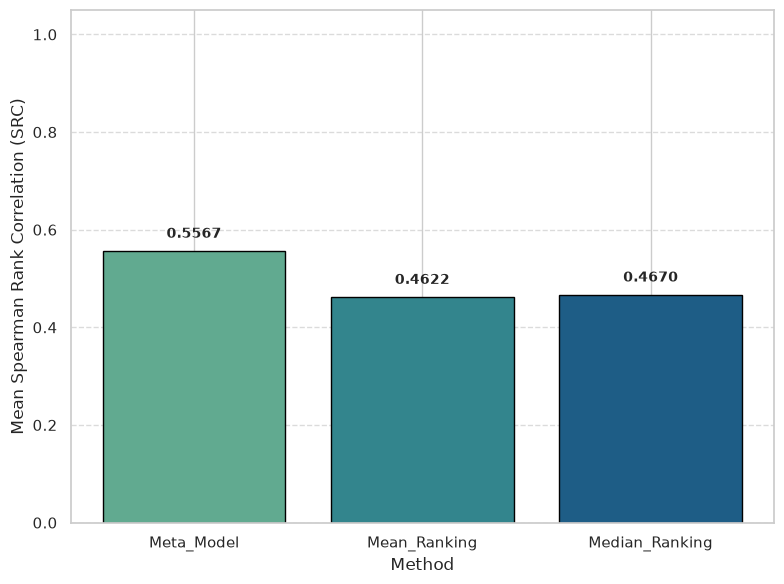

In [41]:
mean_values_all_metafeatures = df_comparative_all_metafeatures.mean()

colors = sns.color_palette("crest", n_colors=len(mean_values_all_metafeatures))

plt.figure(figsize=(8, 6))

bars = plt.bar(
    mean_values_all_metafeatures.index,
    mean_values_all_metafeatures.values,
    color=colors,
    edgecolor="black"
)

plt.ylabel("Mean Spearman Rank Correlation (SRC)")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.7)

sns.set(style="whitegrid")

plt.tight_layout()

plt.savefig(
    "mean_spearman_src.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()